                                   DATA ANALYSIS REPORT

1. GENERAL INFORMATION
Total number of samples: 618
Number of columns: 22

Available columns:
    1. case_id
    2. gender
    3. age_diag
    4. grade
    5. cancer_history
    6. ajcc_path_tumor_pt
    7. ajcc_path_nodes_pn
    8. ajcc_clin_metastasis_cm
    9. ajcc_path_metastasis_pm
   10. ajcc_path_tumor_stage
   11. vital_status_12
   12. race_Asian
   13. race_Black or African American
   14. race_Hispanic or Latino
   15. race_White
   16. race_other
   17. VHL_mutation
   18. PBMR1_mutation
   19. TTN_mutation
   20. Split
   21. gender_label
   22. vital_status_label

2. DATA OVERVIEW
     case_id  gender  age_diag  grade  cancer_history  ajcc_path_tumor_pt  ajcc_path_nodes_pn  ajcc_clin_metastasis_cm  ajcc_path_metastasis_pm  ajcc_path_tumor_stage  vital_status_12  race_Asian  race_Black or African American  race_Hispanic or Latino  race_White  race_other  VHL_mutation  PBMR1_mutation  TTN_mutation  Split gender_label 

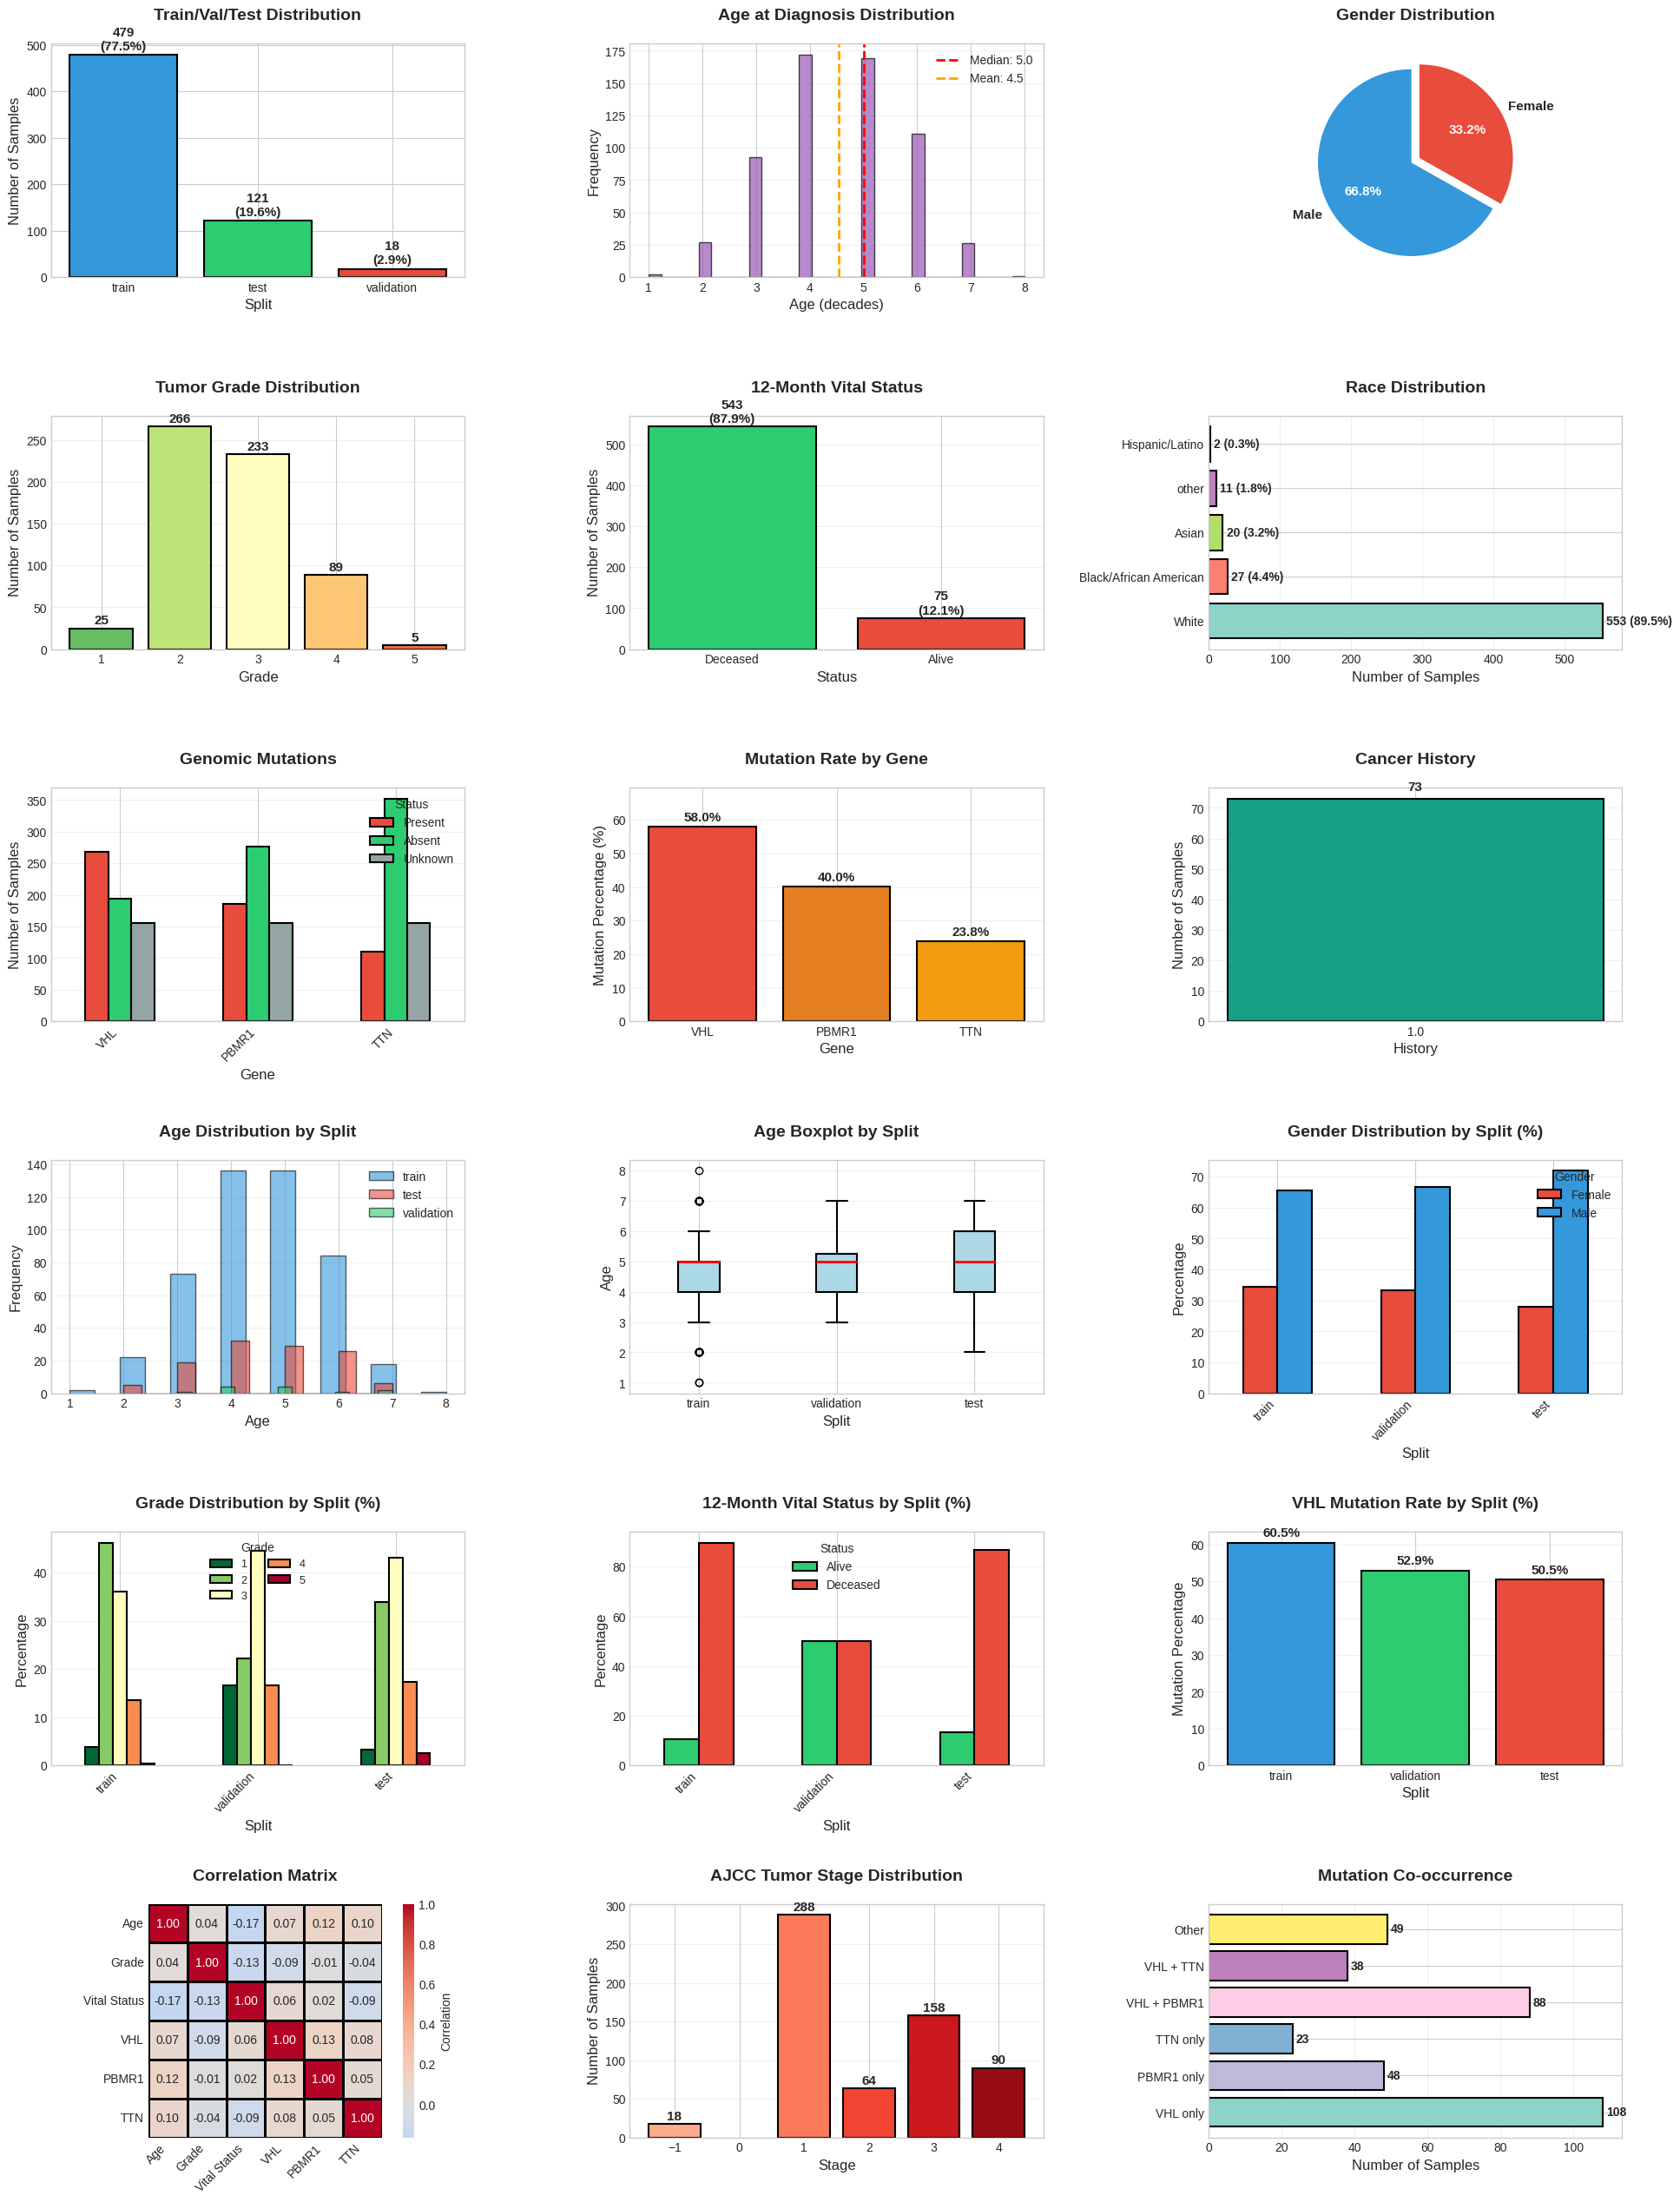

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 24)
plt.rcParams['font.size'] = 10

csv_path = "/media/Data/Yona/WSI CCRCC/tables/clinical+genomic_split.csv"
df = pd.read_csv(csv_path)

df['gender_label'] = df['gender'].map({0: 'Female', 1: 'Male'})
df['vital_status_label'] = df['vital_status_12'].map({0: 'Alive', 1: 'Deceased'})

print("=" * 100)
print(" " * 35 + "DATA ANALYSIS REPORT")
print("=" * 100)

print("\n" + "=" * 100)
print("1. GENERAL INFORMATION")
print("=" * 100)
print(f"Total number of samples: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print("\nAvailable columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

print("\n" + "=" * 100)
print("2. DATA OVERVIEW")
print("=" * 100)
print(df.head(10).to_string())

print("\n" + "=" * 100)
print("3. MISSING VALUES")
print("=" * 100)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_pct.values
})
missing_display = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_display) > 0:
    print(missing_display.to_string(index=False))
else:
    print("No missing values detected")

print("\n" + "=" * 100)
print("4. SPLIT DISTRIBUTION (TRAIN/VAL/TEST)")
print("=" * 100)
split_counts = df['Split'].value_counts()
split_pct = (df['Split'].value_counts(normalize=True) * 100).round(2)
split_df = pd.DataFrame({
    'Split': split_counts.index,
    'Count': split_counts.values,
    'Percentage': split_pct.values
})
print(split_df.to_string(index=False))

fig = plt.figure(figsize=(20, 26))

ax1 = plt.subplot(6, 3, 1)
colors_split = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax1.bar(split_counts.index, split_counts.values, color=colors_split, edgecolor='black', linewidth=1.5)
ax1.set_title('Train/Val/Test Distribution', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Split', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
for bar, v, pct in zip(bars, split_counts.values, split_pct.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2., height + 5,
             f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2 = plt.subplot(6, 3, 2)
age_data = df['age_diag'].dropna()
ax2.hist(age_data, bins=30, edgecolor='black', alpha=0.7, color='#9b59b6')
ax2.set_title('Age at Diagnosis Distribution', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Age (decades)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
median_age = age_data.median()
mean_age = age_data.mean()
ax2.axvline(median_age, color='red', linestyle='--', linewidth=2, label=f'Median: {median_age:.1f}')
ax2.axvline(mean_age, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

ax3 = plt.subplot(6, 3, 3)
gender_counts = df['gender_label'].value_counts()
colors_gender = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax3.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors_gender,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
ax3.set_title('Gender Distribution', fontsize=14, fontweight='bold', pad=20)
for autotext in autotexts:
    autotext.set_color('white')

ax4 = plt.subplot(6, 3, 4)
grade_counts = df['grade'].value_counts().sort_index()
colors_grade = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grade_counts)))
bars = ax4.bar(grade_counts.index, grade_counts.values, color=colors_grade, edgecolor='black', linewidth=1.5)
ax4.set_title('Tumor Grade Distribution', fontsize=14, fontweight='bold', pad=20)
ax4.set_xlabel('Grade', fontsize=12)
ax4.set_ylabel('Number of Samples', fontsize=12)
ax4.set_xticks(grade_counts.index)
for bar, v in zip(bars, grade_counts.values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width() / 2., height + 2,
             f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax4.grid(axis='y', alpha=0.3)

ax5 = plt.subplot(6, 3, 5)
vital_counts = df['vital_status_label'].value_counts()
colors_vital = ['#2ecc71', '#e74c3c']
bars = ax5.bar(vital_counts.index, vital_counts.values, color=colors_vital, edgecolor='black', linewidth=1.5)
ax5.set_title('12-Month Vital Status', fontsize=14, fontweight='bold', pad=20)
ax5.set_xlabel('Status', fontsize=12)
ax5.set_ylabel('Number of Samples', fontsize=12)
for bar, v in zip(bars, vital_counts.values):
    height = bar.get_height()
    pct = v / len(df) * 100
    ax5.text(bar.get_x() + bar.get_width() / 2., height + 5,
             f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax5.grid(axis='y', alpha=0.3)

ax6 = plt.subplot(6, 3, 6)
race_cols = [col for col in df.columns if col.startswith('race_')]
race_data = df[race_cols].sum().sort_values(ascending=False)
race_labels = [col.replace('race_', '').replace(' or ', '/') for col in race_data.index]
colors_race = plt.cm.Set3(np.linspace(0, 1, len(race_data)))
bars = ax6.barh(range(len(race_data)), race_data.values, color=colors_race, edgecolor='black', linewidth=1.5)
ax6.set_title('Race Distribution', fontsize=14, fontweight='bold', pad=20)
ax6.set_xlabel('Number of Samples', fontsize=12)
ax6.set_yticks(range(len(race_data)))
ax6.set_yticklabels(race_labels, fontsize=10)
for bar, v in zip(bars, race_data.values):
    width = bar.get_width()
    pct = v / len(df) * 100
    ax6.text(width + 5, bar.get_y() + bar.get_height() / 2.,
             f'{int(v)} ({pct:.1f}%)', va='center', fontweight='bold', fontsize=10)
ax6.grid(axis='x', alpha=0.3)

ax7 = plt.subplot(6, 3, 7)
mutation_cols = ['VHL_mutation', 'PBMR1_mutation', 'TTN_mutation']
mutation_data = []
for col in mutation_cols:
    present = (df[col] == 1).sum()
    absent = (df[col] == 0).sum()
    unknown = (df[col] == -1).sum()
    mutation_data.append([present, absent, unknown])

mutation_df = pd.DataFrame(
    mutation_data,
    columns=['Present', 'Absent', 'Unknown'],
    index=[col.replace('_mutation', '') for col in mutation_cols]
)

mutation_df.plot(
    kind='bar',
    ax=ax7,
    stacked=False,
    color=['#e74c3c', '#2ecc71', '#95a5a6'],
    edgecolor='black',
    linewidth=1.5
)
ax7.set_title('Genomic Mutations', fontsize=14, fontweight='bold', pad=20)
ax7.set_xlabel('Gene', fontsize=12)
ax7.set_ylabel('Number of Samples', fontsize=12)
ax7.set_xticklabels(ax7.get_xticklabels(), rotation=45, ha='right')
ax7.legend(title='Status', fontsize=10)
ax7.grid(axis='y', alpha=0.3)

ax8 = plt.subplot(6, 3, 8)
mutation_pct = []
for col in mutation_cols:
    total_known = ((df[col] == 0) | (df[col] == 1)).sum()
    pct = (df[col] == 1).sum() / total_known * 100 if total_known > 0 else 0
    mutation_pct.append(pct)

gene_names = [col.replace('_mutation', '') for col in mutation_cols]
colors_mut = ['#e74c3c', '#e67e22', '#f39c12']
bars = ax8.bar(gene_names, mutation_pct, color=colors_mut, edgecolor='black', linewidth=1.5)
ax8.set_title('Mutation Rate by Gene', fontsize=14, fontweight='bold', pad=20)
ax8.set_xlabel('Gene', fontsize=12)
ax8.set_ylabel('Mutation Percentage (%)', fontsize=12)
ax8.set_ylim(0, max(mutation_pct) * 1.2)
for bar, v in zip(bars, mutation_pct):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width() / 2., height + 1,
             f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax8.grid(axis='y', alpha=0.3)

ax9 = plt.subplot(6, 3, 9)
cancer_hist = df['cancer_history'].value_counts()
colors_hist = ['#16a085', '#c0392b']
bars = ax9.bar(range(len(cancer_hist)), cancer_hist.values, color=colors_hist, edgecolor='black', linewidth=1.5)
ax9.set_title('Cancer History', fontsize=14, fontweight='bold', pad=20)
ax9.set_xlabel('History', fontsize=12)
ax9.set_ylabel('Number of Samples', fontsize=12)
ax9.set_xticks(range(len(cancer_hist)))
ax9.set_xticklabels(['No', 'Yes'] if len(cancer_hist) == 2 else cancer_hist.index)
for bar, v in zip(bars, cancer_hist.values):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width() / 2., height + 2,
             f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax9.grid(axis='y', alpha=0.3)

ax10 = plt.subplot(6, 3, 10)
splits = df['Split'].unique()
colors_by_split = {'train': '#3498db', 'validation': '#2ecc71', 'test': '#e74c3c'}
for split in splits:
    data = df[df['Split'] == split]['age_diag'].dropna()
    ax10.hist(data, bins=15, alpha=0.6, label=split, edgecolor='black',
              color=colors_by_split.get(split, '#95a5a6'))
ax10.set_title('Age Distribution by Split', fontsize=14, fontweight='bold', pad=20)
ax10.set_xlabel('Age', fontsize=12)
ax10.set_ylabel('Frequency', fontsize=12)
ax10.legend(fontsize=10)
ax10.grid(axis='y', alpha=0.3)

ax11 = plt.subplot(6, 3, 11)
split_order = ['train', 'validation', 'test']
split_data = [df[df['Split'] == split]['age_diag'].dropna() for split in split_order]
ax11.boxplot(
    split_data,
    labels=split_order,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)
ax11.set_title('Age Boxplot by Split', fontsize=14, fontweight='bold', pad=20)
ax11.set_xlabel('Split', fontsize=12)
ax11.set_ylabel('Age', fontsize=12)
ax11.grid(axis='y', alpha=0.3)

ax12 = plt.subplot(6, 3, 12)
gender_split = pd.crosstab(df['Split'], df['gender_label'], normalize='index') * 100
gender_split = gender_split.reindex(split_order)
gender_split.plot(kind='bar', ax=ax12, color=['#e74c3c', '#3498db'], edgecolor='black', linewidth=1.5)
ax12.set_title('Gender Distribution by Split (%)', fontsize=14, fontweight='bold', pad=20)
ax12.set_xlabel('Split', fontsize=12)
ax12.set_ylabel('Percentage', fontsize=12)
ax12.set_xticklabels(ax12.get_xticklabels(), rotation=45, ha='right')
ax12.legend(title='Gender', fontsize=10)
ax12.grid(axis='y', alpha=0.3)

ax13 = plt.subplot(6, 3, 13)
grade_split = pd.crosstab(df['Split'], df['grade'], normalize='index') * 100
grade_split = grade_split.reindex(split_order)
grade_split.plot(kind='bar', ax=ax13, stacked=False, colormap='RdYlGn_r', edgecolor='black', linewidth=1.5)
ax13.set_title('Grade Distribution by Split (%)', fontsize=14, fontweight='bold', pad=20)
ax13.set_xlabel('Split', fontsize=12)
ax13.set_ylabel('Percentage', fontsize=12)
ax13.set_xticklabels(ax13.get_xticklabels(), rotation=45, ha='right')
ax13.legend(title='Grade', fontsize=9, ncol=2)
ax13.grid(axis='y', alpha=0.3)

ax14 = plt.subplot(6, 3, 14)
vital_split = pd.crosstab(df['Split'], df['vital_status_label'], normalize='index') * 100
vital_split = vital_split.reindex(split_order)
vital_split.plot(kind='bar', ax=ax14, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax14.set_title('12-Month Vital Status by Split (%)', fontsize=14, fontweight='bold', pad=20)
ax14.set_xlabel('Split', fontsize=12)
ax14.set_ylabel('Percentage', fontsize=12)
ax14.set_xticklabels(ax14.get_xticklabels(), rotation=45, ha='right')
ax14.legend(title='Status', fontsize=10)
ax14.grid(axis='y', alpha=0.3)

ax15 = plt.subplot(6, 3, 15)
vhl_split_data = []
for split in split_order:
    split_df_local = df[df['Split'] == split]
    total_known = ((split_df_local['VHL_mutation'] == 0) | (split_df_local['VHL_mutation'] == 1)).sum()
    pct_mut = (split_df_local['VHL_mutation'] == 1).sum() / total_known * 100 if total_known > 0 else 0
    vhl_split_data.append(pct_mut)

bars = ax15.bar(split_order, vhl_split_data, color=['#3498db', '#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=1.5)
ax15.set_title('VHL Mutation Rate by Split (%)', fontsize=14, fontweight='bold', pad=20)
ax15.set_xlabel('Split', fontsize=12)
ax15.set_ylabel('Mutation Percentage', fontsize=12)
for bar, v in zip(bars, vhl_split_data):
    height = bar.get_height()
    ax15.text(bar.get_x() + bar.get_width() / 2., height + 1,
              f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax15.grid(axis='y', alpha=0.3)

ax16 = plt.subplot(6, 3, 16)
numeric_cols = ['age_diag', 'grade', 'vital_status_12', 'VHL_mutation', 'PBMR1_mutation', 'TTN_mutation']
corr_data = df[numeric_cols].copy().replace(-1, np.nan)
corr_matrix = corr_data.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax16,
    square=True,
    cbar_kws={'label': 'Correlation'},
    linewidths=1,
    linecolor='black'
)
ax16.set_title('Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
labels = ['Age', 'Grade', 'Vital Status', 'VHL', 'PBMR1', 'TTN']
ax16.set_xticklabels(labels, rotation=45, ha='right')
ax16.set_yticklabels(labels, rotation=0)

ax17 = plt.subplot(6, 3, 17)
stage_counts = df['ajcc_path_tumor_stage'].value_counts().sort_index()
colors_stage = plt.cm.Reds(np.linspace(0.3, 0.9, len(stage_counts)))
bars = ax17.bar(stage_counts.index, stage_counts.values, color=colors_stage, edgecolor='black', linewidth=1.5)
ax17.set_title('AJCC Tumor Stage Distribution', fontsize=14, fontweight='bold', pad=20)
ax17.set_xlabel('Stage', fontsize=12)
ax17.set_ylabel('Number of Samples', fontsize=12)
for bar, v in zip(bars, stage_counts.values):
    height = bar.get_height()
    ax17.text(bar.get_x() + bar.get_width() / 2., height + 2,
              f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax17.grid(axis='y', alpha=0.3)

ax18 = plt.subplot(6, 3, 18)
mutation_combinations = []
labels_comb = []

vhl_only = ((df['VHL_mutation'] == 1) & (df['PBMR1_mutation'] != 1) & (df['TTN_mutation'] != 1)).sum()
mutation_combinations.append(vhl_only)
labels_comb.append('VHL only')

pbmr1_only = ((df['PBMR1_mutation'] == 1) & (df['VHL_mutation'] != 1) & (df['TTN_mutation'] != 1)).sum()
mutation_combinations.append(pbmr1_only)
labels_comb.append('PBMR1 only')

ttn_only = ((df['TTN_mutation'] == 1) & (df['VHL_mutation'] != 1) & (df['PBMR1_mutation'] != 1)).sum()
mutation_combinations.append(ttn_only)
labels_comb.append('TTN only')

vhl_pbmr1 = ((df['VHL_mutation'] == 1) & (df['PBMR1_mutation'] == 1) & (df['TTN_mutation'] != 1)).sum()
mutation_combinations.append(vhl_pbmr1)
labels_comb.append('VHL + PBMR1')

vhl_ttn = ((df['VHL_mutation'] == 1) & (df['TTN_mutation'] == 1) & (df['PBMR1_mutation'] != 1)).sum()
mutation_combinations.append(vhl_ttn)
labels_comb.append('VHL + TTN')

other = ((df['PBMR1_mutation'] == 1) & (df['TTN_mutation'] == 1)).sum()
mutation_combinations.append(other)
labels_comb.append('Other')

colors_comb = plt.cm.Set3(np.linspace(0, 1, len(mutation_combinations)))
bars = ax18.barh(range(len(labels_comb)), mutation_combinations, color=colors_comb, edgecolor='black', linewidth=1.5)
ax18.set_title('Mutation Co-occurrence', fontsize=14, fontweight='bold', pad=20)
ax18.set_xlabel('Number of Samples', fontsize=12)
ax18.set_yticks(range(len(labels_comb)))
ax18.set_yticklabels(labels_comb, fontsize=10)
for bar, v in zip(bars, mutation_combinations):
    width = bar.get_width()
    ax18.text(width + 1, bar.get_y() + bar.get_height() / 2.,
              f'{int(v)}', va='center', fontweight='bold', fontsize=10)
ax18.grid(axis='x', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('complete_distribution_analysis.png', dpi=300, bbox_inches='tight')
print("\nPlot saved: complete_distribution_analysis.png\n")

print("\n" + "=" * 100)
print("5. TRAIN/VAL/TEST STRATIFICATION CHECK")
print("=" * 100)

print("\nCHI-SQUARE TEST FOR CATEGORICAL VARIABLES")
print("-" * 100)

contingency_gender = pd.crosstab(df['Split'], df['gender'])
chi2_gender, p_gender, dof_gender, expected_gender = stats.chi2_contingency(contingency_gender)
print(f"\nGender:")
print(f"   Chi² = {chi2_gender:.4f}, p-value = {p_gender:.4f}")
print("   Good stratification (no significant difference)" if p_gender > 0.05 else "   Stratification should be checked (significant difference detected)")

contingency_grade = pd.crosstab(df['Split'], df['grade'])
chi2_grade, p_grade, dof_grade, expected_grade = stats.chi2_contingency(contingency_grade)
print(f"\nTumor grade:")
print(f"   Chi² = {chi2_grade:.4f}, p-value = {p_grade:.4f}")
print("   Good stratification (no significant difference)" if p_grade > 0.05 else "   Stratification should be checked (significant difference detected)")

contingency_vital = pd.crosstab(df['Split'], df['vital_status_12'])
chi2_vital, p_vital, dof_vital, expected_vital = stats.chi2_contingency(contingency_vital)
print(f"\n12-month vital status:")
print(f"   Chi² = {chi2_vital:.4f}, p-value = {p_vital:.4f}")
print("   Good stratification (no significant difference)" if p_vital > 0.05 else "   Stratification should be checked (significant difference detected)")

df_vhl = df[df['VHL_mutation'].isin([0, 1])]
if len(df_vhl) > 0:
    contingency_vhl = pd.crosstab(df_vhl['Split'], df_vhl['VHL_mutation'])
    chi2_vhl, p_vhl, dof_vhl, expected_vhl = stats.chi2_contingency(contingency_vhl)
    print(f"\nVHL mutation:")
    print(f"   Chi² = {chi2_vhl:.4f}, p-value = {p_vhl:.4f}")
    print("   Good stratification (no significant difference)" if p_vhl > 0.05 else "   Stratification should be checked (significant difference detected)")

print("\n" + "-" * 100)
print("ANOVA TEST FOR AGE")
print("-" * 100)

splits = ['train', 'validation', 'test']
age_groups = [df[df['Split'] == split]['age_diag'].dropna() for split in splits]
f_stat, p_anova = stats.f_oneway(*age_groups)
print(f"\nAge at diagnosis:")
print(f"   F-statistic = {f_stat:.4f}, p-value = {p_anova:.4f}")
print("   Good stratification (no significant difference)" if p_anova > 0.05 else "   Stratification should be checked (significant difference detected)")

print("\n" + "-" * 100)
print("AGE DESCRIPTIVE STATISTICS BY SPLIT")
print("-" * 100)
age_stats = df.groupby('Split')['age_diag'].describe().round(2)
print(age_stats.to_string())

print("\n" + "=" * 100)
print("6. SUMMARY TABLE OF PROPORTIONS BY SPLIT")
print("=" * 100)

summary_data = []

for split in splits:
    split_df_local = df[df['Split'] == split]
    n = len(split_df_local)

    vhl_known = split_df_local[split_df_local['VHL_mutation'].isin([0, 1])]
    pct_vhl = (vhl_known['VHL_mutation'] == 1).sum() / len(vhl_known) * 100 if len(vhl_known) > 0 else 0
    pct_deceased = (split_df_local['vital_status_12'] == 1).sum() / n * 100
    pct_high_grade = (split_df_local['grade'] >= 3).sum() / n * 100

    row = {
        'Split': split,
        'N': n,
        '%_total': f"{n / len(df) * 100:.1f}%",
        'Age_mean±std': f"{split_df_local['age_diag'].mean():.1f}±{split_df_local['age_diag'].std():.1f}",
        '%_Male': f"{(split_df_local['gender'] == 1).sum() / n * 100:.1f}%",
        '%_Grade≥3': f"{pct_high_grade:.1f}%",
        '%_VHL_mut': f"{pct_vhl:.1f}%",
        '%_Death_12m': f"{pct_deceased:.1f}%"
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "=" * 100)
print("7. SUMMARY AND RECOMMENDATIONS")
print("=" * 100)

print("\nKEY POINTS:")
print(f"   • Total samples: {len(df)}")
print(f"   • Distribution: Train={split_counts['train']} ({split_pct['train']:.1f}%), ", end="")
print(f"Val={split_counts['validation']} ({split_pct['validation']:.1f}%), ", end="")
print(f"Test={split_counts['test']} ({split_pct['test']:.1f}%)")
print(f"   • Mean age: {df['age_diag'].mean():.1f} ± {df['age_diag'].std():.1f}")
print(f"   • Male/Female ratio: {(df['gender'] == 1).sum()}:{(df['gender'] == 0).sum()}")
print(f"   • 12-month mortality rate: {(df['vital_status_12'] == 1).sum() / len(df) * 100:.1f}%")

print("\nWARNING:")
print(f"   • Very small validation set: {split_counts['validation']} samples ({split_pct['validation']:.1f}%)")
print("   • Risk of high variance in validation evaluation")
print("   • Consider using cross-validation")

vhl_known = df[df['VHL_mutation'].isin([0, 1])]
vhl_rate = (vhl_known['VHL_mutation'] == 1).sum() / len(vhl_known) * 100
print(f"\nMUTATIONS:")
print(f"   • VHL mutation rate: {vhl_rate:.1f}% (most frequently mutated gene in ccRCC)")

print("\nSTRATIFICATION:")
significant_vars = []
if p_gender <= 0.05:
    significant_vars.append("gender")
if p_grade <= 0.05:
    significant_vars.append("grade")
if p_vital <= 0.05:
    significant_vars.append("vital status")
if p_anova <= 0.05:
    significant_vars.append("age")

if not significant_vars:
    print("   • Excellent stratification across all tested variables")
else:
    print(f"   • Significant differences detected for: {', '.join(significant_vars)}")
    print("   • Consider more advanced stratification if needed")

print("\n" + "=" * 100)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 100)
print("\nGenerated files:")
print("   • complete_distribution_analysis.png")
print("\nRecommended next steps:")
print("   1. Visually inspect the plots")
print("   2. Consider increasing the validation set size")
print("   3. Check for age outliers")
print("   4. Analyze missing values (cancer_history: 88% missing)")

plt.show()

                                        RAPPORT DE VÉRIFICATION DE LA STRATIFICATION

📊 Nombre total d'échantillons: 618

📁 Distribution des splits:
   • train       :  479 échantillons (77.51%)
   • validation  :   18 échantillons ( 2.91%)
   • test        :  121 échantillons (19.58%)

ANALYSE DÉTAILLÉE DE CHAQUE FEATURE

------------------------------------------------------------------------------------------------------------------------
1. GENRE (gender)
------------------------------------------------------------------------------------------------------------------------

📊 Test Chi²: χ² = 1.7560, p-value = 0.4156
   ✓ BONNE stratification: Pas de différence significative

📈 Distribution par split (%):
gender              0          1
Split                           
test        28.099174  71.900826
train       34.446764  65.553236
validation  33.333333  66.666667

📋 Effectifs absolus:
gender        0    1
Split               
test         34   87
train       165  314
validation

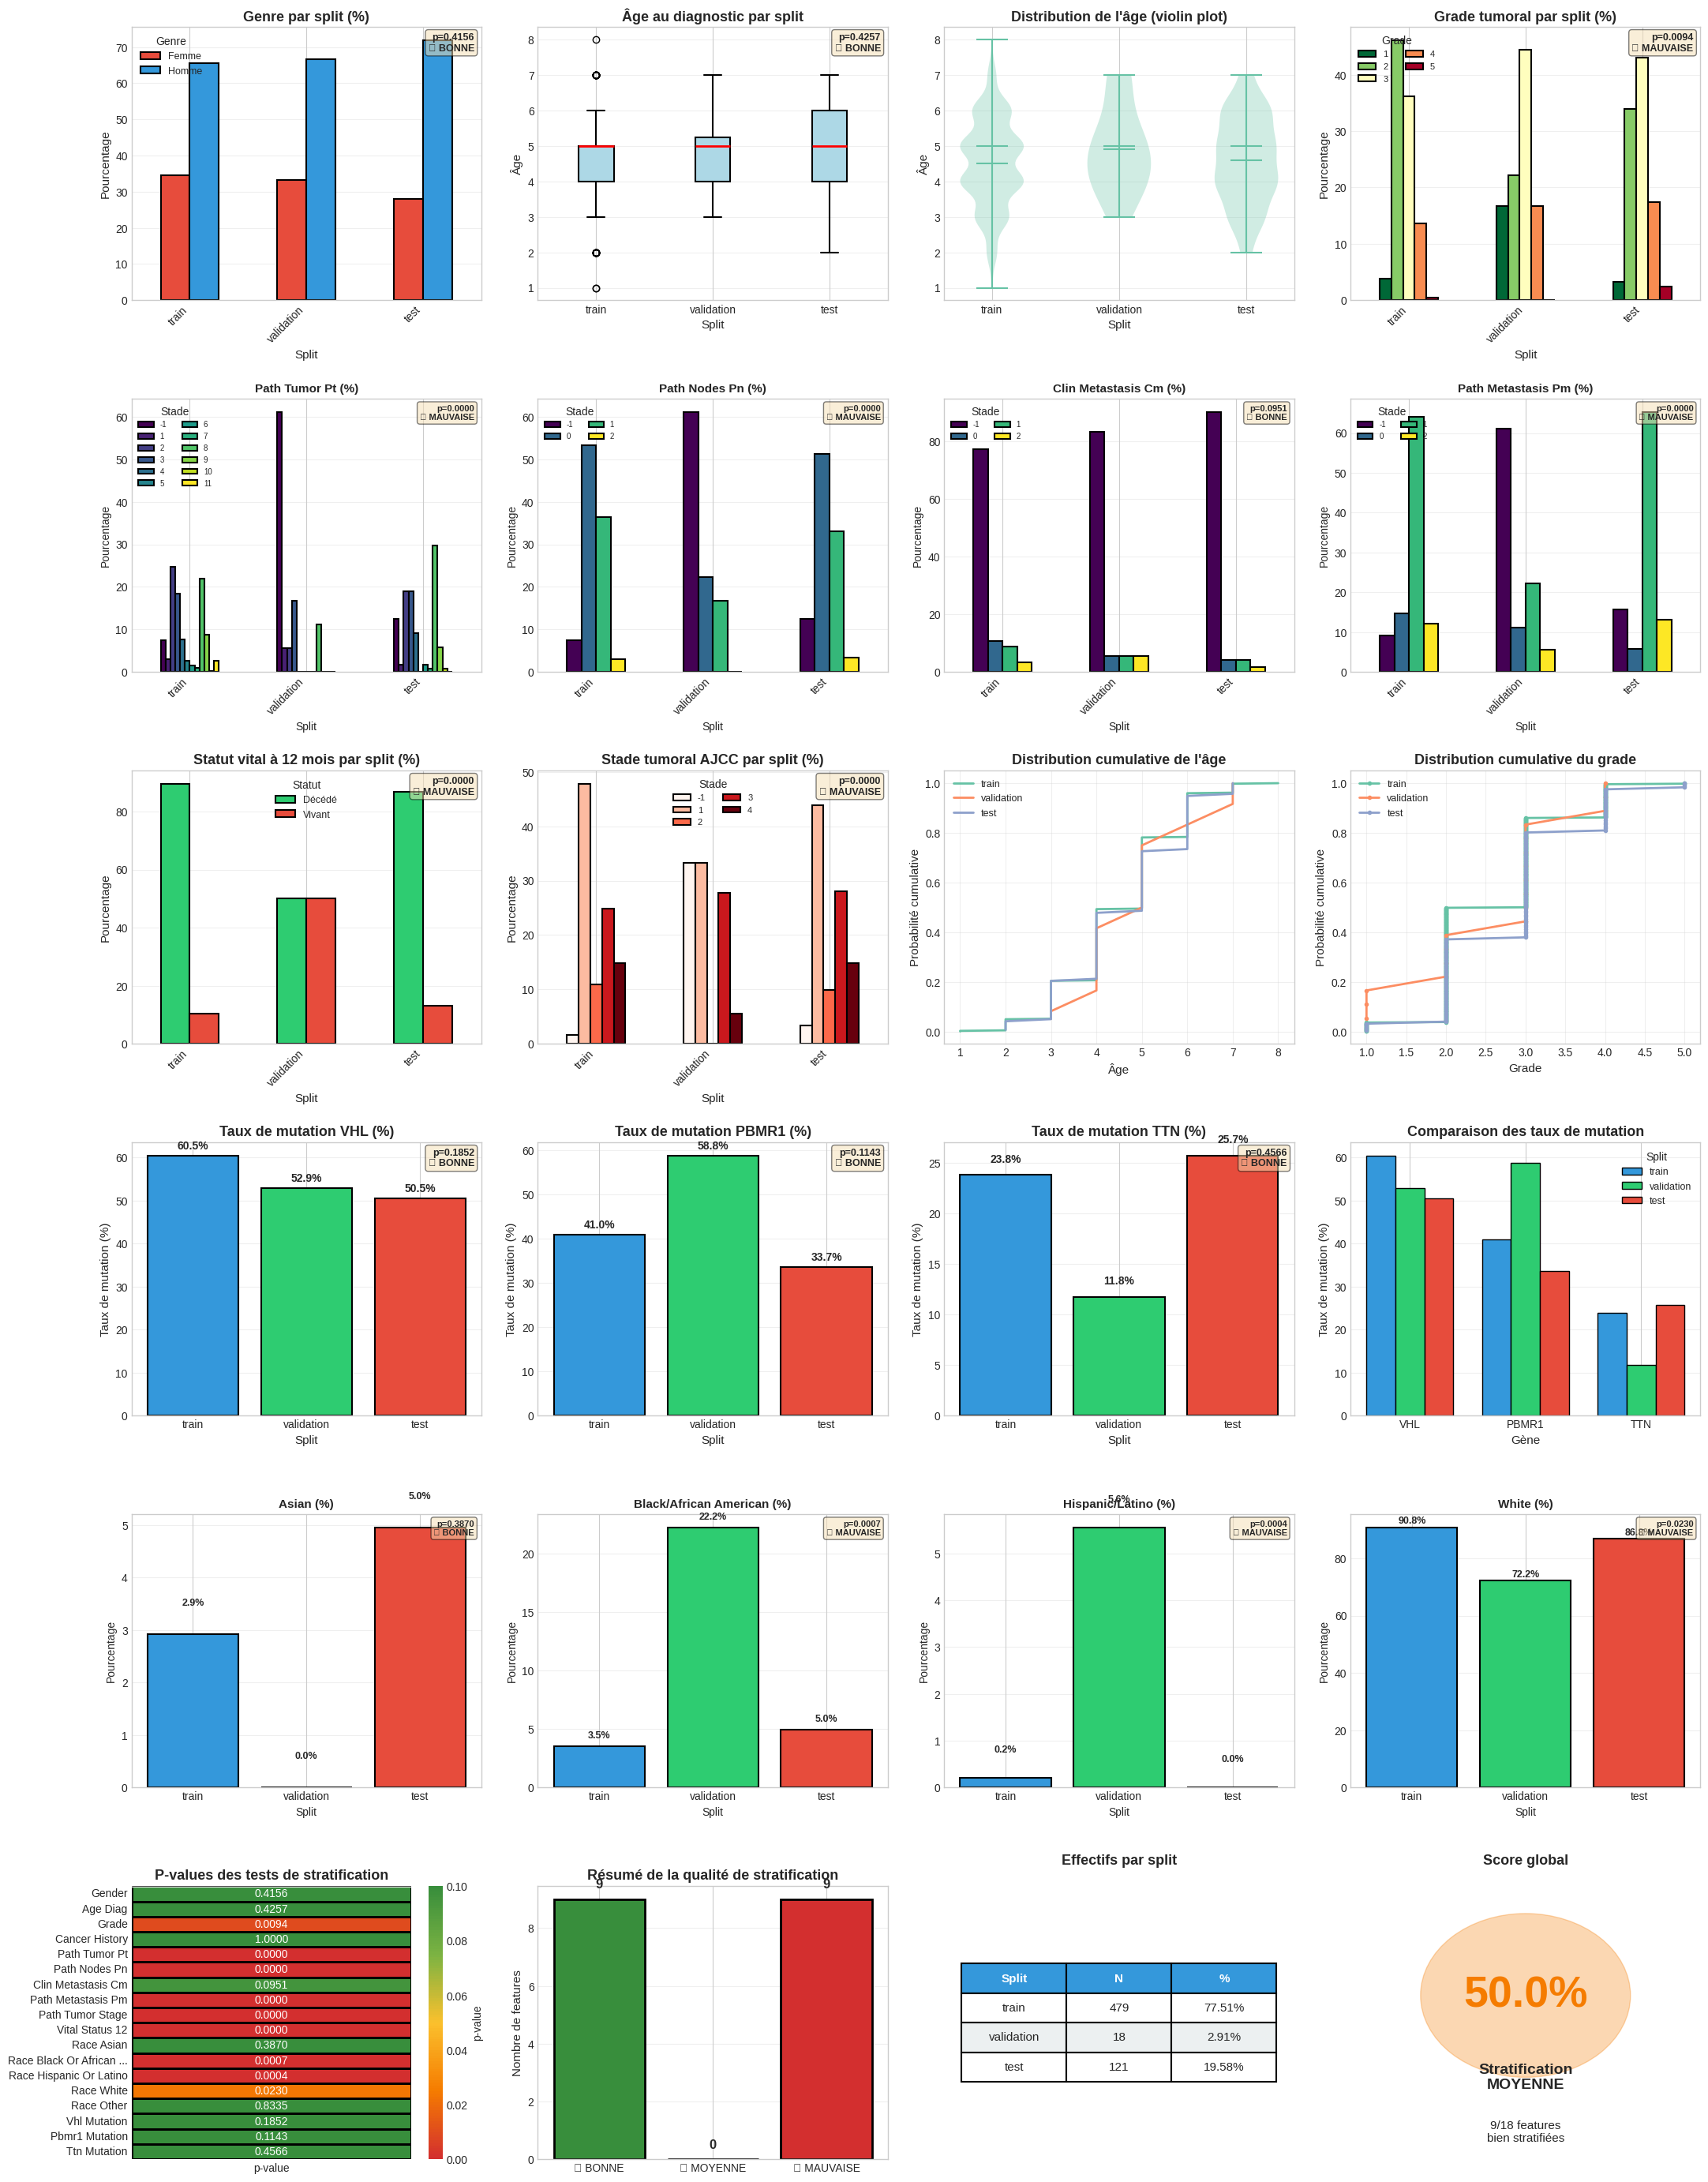

In [1]:
"""
Script de vérification de la stratification Train/Validation/Test
Vérifie que chaque feature est bien distribuée de manière similaire entre les splits
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ks_2samp
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (22, 28)
plt.rcParams['font.size'] = 10

# ============================================================================
# CHARGEMENT DES DONNÉES
# ============================================================================

csv_path = "/media/Data/Yona/WSI CCRCC/tables/clinical+genomic_split.csv"
df = pd.read_csv(csv_path)

# Ordre des splits
split_order = ['train', 'validation', 'test']

print("="*120)
print(" "*40 + "RAPPORT DE VÉRIFICATION DE LA STRATIFICATION")
print("="*120)

print(f"\n📊 Nombre total d'échantillons: {len(df)}")
print(f"\n📁 Distribution des splits:")
for split in split_order:
    count = len(df[df['Split'] == split])
    pct = count / len(df) * 100
    print(f"   • {split:12s}: {count:4d} échantillons ({pct:5.2f}%)")

# ============================================================================
# FONCTIONS D'ANALYSE
# ============================================================================

def test_categorical_stratification(df, feature, split_col='Split'):
    """Test Chi² pour variable catégorielle"""
    contingency = pd.crosstab(df[split_col], df[feature])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    # Calculer les proportions par split
    proportions = pd.crosstab(df[split_col], df[feature], normalize='index') * 100
    
    return {
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'proportions': proportions,
        'contingency': contingency
    }

def test_continuous_stratification(df, feature, split_col='Split'):
    """Test ANOVA pour variable continue"""
    groups = [df[df[split_col] == split][feature].dropna() for split in split_order]
    f_stat, p_value = f_oneway(*groups)
    
    # Statistiques descriptives par split
    stats_by_split = df.groupby(split_col)[feature].agg(['mean', 'std', 'median', 'min', 'max', 'count'])
    
    return {
        'f_stat': f_stat,
        'p_value': p_value,
        'stats': stats_by_split,
        'groups': groups
    }

def interpret_p_value(p_value, alpha=0.05):
    """Interpréter la p-value"""
    if p_value > alpha:
        return "✓ BONNE", "Pas de différence significative"
    elif p_value > alpha/2:
        return "⚠ MOYENNE", "Différence marginale"
    else:
        return "✗ MAUVAISE", "Différence significative"

# ============================================================================
# ANALYSE DÉTAILLÉE PAR FEATURE
# ============================================================================

print("\n" + "="*120)
print("ANALYSE DÉTAILLÉE DE CHAQUE FEATURE")
print("="*120)

results = {}

# ----------------------------------------------------------------------------
# 1. GENRE
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("1. GENRE (gender)")
print("-"*120)

gender_map = {0: 'Femme', 1: 'Homme'}
df['gender_label'] = df['gender'].map(gender_map)

result_gender = test_categorical_stratification(df, 'gender')
results['gender'] = result_gender

print(f"\n📊 Test Chi²: χ² = {result_gender['chi2']:.4f}, p-value = {result_gender['p_value']:.4f}")
status, msg = interpret_p_value(result_gender['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution par split (%):")
print(result_gender['proportions'].to_string())

print("\n📋 Effectifs absolus:")
print(result_gender['contingency'].to_string())

# ----------------------------------------------------------------------------
# 2. ÂGE AU DIAGNOSTIC
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("2. ÂGE AU DIAGNOSTIC (age_diag)")
print("-"*120)

result_age = test_continuous_stratification(df, 'age_diag')
results['age_diag'] = result_age

print(f"\n📊 Test ANOVA: F = {result_age['f_stat']:.4f}, p-value = {result_age['p_value']:.4f}")
status, msg = interpret_p_value(result_age['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Statistiques par split:")
print(result_age['stats'].round(2).to_string())

# Tests pairwise KS
print("\n📉 Tests de Kolmogorov-Smirnov (comparaisons pairwise):")
for i, split1 in enumerate(split_order):
    for split2 in split_order[i+1:]:
        data1 = df[df['Split'] == split1]['age_diag'].dropna()
        data2 = df[df['Split'] == split2]['age_diag'].dropna()
        ks_stat, ks_p = ks_2samp(data1, data2)
        status_ks = "✓" if ks_p > 0.05 else "✗"
        print(f"   {status_ks} {split1} vs {split2}: KS = {ks_stat:.4f}, p = {ks_p:.4f}")

# ----------------------------------------------------------------------------
# 3. GRADE TUMORAL
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("3. GRADE TUMORAL (grade)")
print("-"*120)

result_grade = test_categorical_stratification(df, 'grade')
results['grade'] = result_grade

print(f"\n📊 Test Chi²: χ² = {result_grade['chi2']:.4f}, p-value = {result_grade['p_value']:.4f}")
status, msg = interpret_p_value(result_grade['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution par split (%):")
print(result_grade['proportions'].to_string())

print("\n📋 Effectifs absolus:")
print(result_grade['contingency'].to_string())

# ----------------------------------------------------------------------------
# 4. HISTORIQUE DE CANCER
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("4. HISTORIQUE DE CANCER (cancer_history)")
print("-"*120)

n_missing = df['cancer_history'].isna().sum()
pct_missing = n_missing / len(df) * 100
print(f"\n⚠️  ATTENTION: {n_missing} valeurs manquantes ({pct_missing:.1f}%)")

if n_missing < len(df):
    df_cancer = df.dropna(subset=['cancer_history'])
    result_cancer = test_categorical_stratification(df_cancer, 'cancer_history')
    results['cancer_history'] = result_cancer
    
    print(f"\n📊 Test Chi² (sur {len(df_cancer)} échantillons): χ² = {result_cancer['chi2']:.4f}, p-value = {result_cancer['p_value']:.4f}")
    status, msg = interpret_p_value(result_cancer['p_value'])
    print(f"   {status} stratification: {msg}")
    
    print("\n📈 Distribution par split (%):")
    print(result_cancer['proportions'].to_string())

# ----------------------------------------------------------------------------
# 5. STADES AJCC
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("5. STADES AJCC")
print("-"*120)

ajcc_features = ['ajcc_path_tumor_pt', 'ajcc_path_nodes_pn', 
                 'ajcc_clin_metastasis_cm', 'ajcc_path_metastasis_pm', 
                 'ajcc_path_tumor_stage']

for feat in ajcc_features:
    result = test_categorical_stratification(df, feat)
    results[feat] = result
    
    print(f"\n📊 {feat}:")
    print(f"   Test Chi²: χ² = {result['chi2']:.4f}, p-value = {result['p_value']:.4f}")
    status, msg = interpret_p_value(result['p_value'])
    print(f"   {status} stratification: {msg}")
    
    print("\n   Distribution par split (%):")
    print("   " + result['proportions'].to_string().replace('\n', '\n   '))

# ----------------------------------------------------------------------------
# 6. STATUT VITAL À 12 MOIS
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("6. STATUT VITAL À 12 MOIS (vital_status_12)")
print("-"*120)

vital_map = {0: 'Vivant', 1: 'Décédé'}
df['vital_status_label'] = df['vital_status_12'].map(vital_map)

result_vital = test_categorical_stratification(df, 'vital_status_12')
results['vital_status_12'] = result_vital

print(f"\n📊 Test Chi²: χ² = {result_vital['chi2']:.4f}, p-value = {result_vital['p_value']:.4f}")
status, msg = interpret_p_value(result_vital['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution par split (%):")
vital_prop_labeled = pd.crosstab(df['Split'], df['vital_status_label'], normalize='index') * 100
print(vital_prop_labeled.to_string())

print("\n📋 Effectifs absolus:")
vital_cont_labeled = pd.crosstab(df['Split'], df['vital_status_label'])
print(vital_cont_labeled.to_string())

# Taux de survie
print("\n💓 Taux de survie à 12 mois par split:")
for split in split_order:
    split_df = df[df['Split'] == split]
    survival_rate = (split_df['vital_status_12'] == 0).sum() / len(split_df) * 100
    print(f"   • {split:12s}: {survival_rate:.2f}%")

# ----------------------------------------------------------------------------
# 7. DISTRIBUTION RACIALE
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("7. DISTRIBUTION RACIALE")
print("-"*120)

race_cols = [col for col in df.columns if col.startswith('race_')]

for race_col in race_cols:
    race_name = race_col.replace('race_', '')
    result = test_categorical_stratification(df, race_col)
    results[race_col] = result
    
    print(f"\n📊 {race_name}:")
    print(f"   Test Chi²: χ² = {result['chi2']:.4f}, p-value = {result['p_value']:.4f}")
    status, msg = interpret_p_value(result['p_value'])
    print(f"   {status} stratification: {msg}")
    
    # Proportion par split
    race_prop = df.groupby('Split')[race_col].mean() * 100
    print(f"\n   Proportion par split (%):")
    for split in split_order:
        print(f"      • {split:12s}: {race_prop[split]:.2f}%")

# ----------------------------------------------------------------------------
# 8. MUTATIONS GÉNOMIQUES
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("8. MUTATIONS GÉNOMIQUES")
print("-"*120)

mutation_cols = ['VHL_mutation', 'PBMR1_mutation', 'TTN_mutation']

for mut_col in mutation_cols:
    gene_name = mut_col.replace('_mutation', '')
    
    # Exclure les valeurs -1 (inconnues)
    df_mut = df[df[mut_col].isin([0, 1])]
    
    if len(df_mut) > 0:
        result = test_categorical_stratification(df_mut, mut_col)
        results[mut_col] = result
        
        print(f"\n📊 Mutation {gene_name}:")
        print(f"   Échantillons avec information: {len(df_mut)}/{len(df)}")
        print(f"   Test Chi²: χ² = {result['chi2']:.4f}, p-value = {result['p_value']:.4f}")
        status, msg = interpret_p_value(result['p_value'])
        print(f"   {status} stratification: {msg}")
        
        # Taux de mutation par split
        print(f"\n   Taux de mutation par split (%):")
        for split in split_order:
            split_df = df_mut[df_mut['Split'] == split]
            if len(split_df) > 0:
                mut_rate = (split_df[mut_col] == 1).sum() / len(split_df) * 100
                n_mut = (split_df[mut_col] == 1).sum()
                print(f"      • {split:12s}: {mut_rate:5.2f}% ({n_mut}/{len(split_df)})")

# ============================================================================
# VISUALISATIONS
# ============================================================================

print("\n" + "="*120)
print("GÉNÉRATION DES VISUALISATIONS")
print("="*120)

fig = plt.figure(figsize=(22, 28))

colors_split = {'train': '#3498db', 'validation': '#2ecc71', 'test': '#e74c3c'}

# ----------------------------------------------------------------------------
# LIGNE 1: GENRE, ÂGE, GRADE
# ----------------------------------------------------------------------------

# 1. Genre par split
ax1 = plt.subplot(6, 4, 1)
gender_prop = pd.crosstab(df['Split'], df['gender_label'], normalize='index') * 100
gender_prop = gender_prop.reindex(split_order)
gender_prop.plot(kind='bar', ax=ax1, color=['#e74c3c', '#3498db'], 
                 edgecolor='black', linewidth=1.5)
ax1.set_title('Genre par split (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Split', fontsize=11)
ax1.set_ylabel('Pourcentage', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend(title='Genre', fontsize=9)
ax1.grid(axis='y', alpha=0.3)
# Ajouter p-value
p_val = results['gender']['p_value']
status, _ = interpret_p_value(p_val)
ax1.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax1.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 2. Boxplot âge par split
ax2 = plt.subplot(6, 4, 2)
split_data = [df[df['Split'] == split]['age_diag'].dropna() for split in split_order]
bp = ax2.boxplot(split_data, labels=split_order, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))
ax2.set_title('Âge au diagnostic par split', fontsize=13, fontweight='bold')
ax2.set_xlabel('Split', fontsize=11)
ax2.set_ylabel('Âge', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
# Ajouter p-value
p_val = results['age_diag']['p_value']
status, _ = interpret_p_value(p_val)
ax2.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 3. Violin plot âge par split
ax3 = plt.subplot(6, 4, 3)
df_age = df.dropna(subset=['age_diag'])
parts = ax3.violinplot([df_age[df_age['Split'] == split]['age_diag'] for split in split_order],
                        positions=range(len(split_order)), showmeans=True, showmedians=True)
ax3.set_xticks(range(len(split_order)))
ax3.set_xticklabels(split_order)
ax3.set_title('Distribution de l\'âge (violin plot)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Split', fontsize=11)
ax3.set_ylabel('Âge', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# 4. Grade par split
ax4 = plt.subplot(6, 4, 4)
grade_prop = pd.crosstab(df['Split'], df['grade'], normalize='index') * 100
grade_prop = grade_prop.reindex(split_order)
grade_prop.plot(kind='bar', ax=ax4, stacked=False, colormap='RdYlGn_r',
                edgecolor='black', linewidth=1.5)
ax4.set_title('Grade tumoral par split (%)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Split', fontsize=11)
ax4.set_ylabel('Pourcentage', fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(title='Grade', fontsize=8, ncol=2)
ax4.grid(axis='y', alpha=0.3)
# Ajouter p-value
p_val = results['grade']['p_value']
status, _ = interpret_p_value(p_val)
ax4.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax4.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# ----------------------------------------------------------------------------
# LIGNE 2: STADES AJCC
# ----------------------------------------------------------------------------

for idx, feat in enumerate(['ajcc_path_tumor_pt', 'ajcc_path_nodes_pn', 
                            'ajcc_clin_metastasis_cm', 'ajcc_path_metastasis_pm'], start=5):
    ax = plt.subplot(6, 4, idx)
    feat_prop = pd.crosstab(df['Split'], df[feat], normalize='index') * 100
    feat_prop = feat_prop.reindex(split_order)
    feat_prop.plot(kind='bar', ax=ax, stacked=False, colormap='viridis',
                   edgecolor='black', linewidth=1.5)
    ax.set_title(f'{feat.replace("ajcc_", "").replace("_", " ").title()} (%)', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Split', fontsize=10)
    ax.set_ylabel('Pourcentage', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Stade', fontsize=7, ncol=2)
    ax.grid(axis='y', alpha=0.3)
    # Ajouter p-value
    p_val = results[feat]['p_value']
    status, _ = interpret_p_value(p_val)
    ax.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=8, fontweight='bold')

# ----------------------------------------------------------------------------
# LIGNE 3: STATUT VITAL ET STADE TUMORAL
# ----------------------------------------------------------------------------

# 9. Statut vital par split
ax9 = plt.subplot(6, 4, 9)
vital_prop = pd.crosstab(df['Split'], df['vital_status_label'], normalize='index') * 100
vital_prop = vital_prop.reindex(split_order)
vital_prop.plot(kind='bar', ax=ax9, color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=1.5)
ax9.set_title('Statut vital à 12 mois par split (%)', fontsize=13, fontweight='bold')
ax9.set_xlabel('Split', fontsize=11)
ax9.set_ylabel('Pourcentage', fontsize=11)
ax9.set_xticklabels(ax9.get_xticklabels(), rotation=45, ha='right')
ax9.legend(title='Statut', fontsize=9)
ax9.grid(axis='y', alpha=0.3)
# Ajouter p-value
p_val = results['vital_status_12']['p_value']
status, _ = interpret_p_value(p_val)
ax9.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax9.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 10. Stade tumoral global
ax10 = plt.subplot(6, 4, 10)
stage_prop = pd.crosstab(df['Split'], df['ajcc_path_tumor_stage'], normalize='index') * 100
stage_prop = stage_prop.reindex(split_order)
stage_prop.plot(kind='bar', ax=ax10, stacked=False, colormap='Reds',
                edgecolor='black', linewidth=1.5)
ax10.set_title('Stade tumoral AJCC par split (%)', fontsize=13, fontweight='bold')
ax10.set_xlabel('Split', fontsize=11)
ax10.set_ylabel('Pourcentage', fontsize=11)
ax10.set_xticklabels(ax10.get_xticklabels(), rotation=45, ha='right')
ax10.legend(title='Stade', fontsize=8, ncol=2)
ax10.grid(axis='y', alpha=0.3)
# Ajouter p-value
p_val = results['ajcc_path_tumor_stage']['p_value']
status, _ = interpret_p_value(p_val)
ax10.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
          transform=ax10.transAxes, ha='right', va='top',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
          fontsize=9, fontweight='bold')

# 11-12: Distributions cumulatives
ax11 = plt.subplot(6, 4, 11)
for split in split_order:
    data = df[df['Split'] == split]['age_diag'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax11.plot(sorted_data, cumulative, label=split, linewidth=2)
ax11.set_title('Distribution cumulative de l\'âge', fontsize=13, fontweight='bold')
ax11.set_xlabel('Âge', fontsize=11)
ax11.set_ylabel('Probabilité cumulative', fontsize=11)
ax11.legend(fontsize=9)
ax11.grid(alpha=0.3)

ax12 = plt.subplot(6, 4, 12)
for split in split_order:
    data = df[df['Split'] == split]['grade']
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax12.plot(sorted_data, cumulative, label=split, linewidth=2, marker='o', markersize=3)
ax12.set_title('Distribution cumulative du grade', fontsize=13, fontweight='bold')
ax12.set_xlabel('Grade', fontsize=11)
ax12.set_ylabel('Probabilité cumulative', fontsize=11)
ax12.legend(fontsize=9)
ax12.grid(alpha=0.3)

# ----------------------------------------------------------------------------
# LIGNE 4: MUTATIONS GÉNOMIQUES
# ----------------------------------------------------------------------------

# 13-15: Mutations VHL, PBMR1, TTN
for idx, (mut_col, gene_name) in enumerate(zip(mutation_cols, 
                                                 ['VHL', 'PBMR1', 'TTN']), start=13):
    ax = plt.subplot(6, 4, idx)
    
    # Données de mutation (exclure -1)
    df_mut = df[df[mut_col].isin([0, 1])]
    
    # Calculer les taux par split
    mut_rates = []
    for split in split_order:
        split_df = df_mut[df_mut['Split'] == split]
        if len(split_df) > 0:
            rate = (split_df[mut_col] == 1).sum() / len(split_df) * 100
        else:
            rate = 0
        mut_rates.append(rate)
    
    bars = ax.bar(split_order, mut_rates, 
                  color=[colors_split[s] for s in split_order],
                  edgecolor='black', linewidth=1.5)
    ax.set_title(f'Taux de mutation {gene_name} (%)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Split', fontsize=11)
    ax.set_ylabel('Taux de mutation (%)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for bar, rate in zip(bars, mut_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Ajouter p-value
    if mut_col in results:
        p_val = results[mut_col]['p_value']
        status, _ = interpret_p_value(p_val)
        ax.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9, fontweight='bold')

# 16. Comparaison des mutations
ax16 = plt.subplot(6, 4, 16)
mutation_data = []
for split in split_order:
    split_rates = []
    for mut_col in mutation_cols:
        df_mut = df[(df['Split'] == split) & (df[mut_col].isin([0, 1]))]
        if len(df_mut) > 0:
            rate = (df_mut[mut_col] == 1).sum() / len(df_mut) * 100
        else:
            rate = 0
        split_rates.append(rate)
    mutation_data.append(split_rates)

x = np.arange(len(['VHL', 'PBMR1', 'TTN']))
width = 0.25
for i, (split, data) in enumerate(zip(split_order, mutation_data)):
    ax16.bar(x + i*width, data, width, label=split, 
             color=colors_split[split], edgecolor='black', linewidth=1)

ax16.set_title('Comparaison des taux de mutation', fontsize=13, fontweight='bold')
ax16.set_xlabel('Gène', fontsize=11)
ax16.set_ylabel('Taux de mutation (%)', fontsize=11)
ax16.set_xticks(x + width)
ax16.set_xticklabels(['VHL', 'PBMR1', 'TTN'])
ax16.legend(title='Split', fontsize=9)
ax16.grid(axis='y', alpha=0.3)

# ----------------------------------------------------------------------------
# LIGNE 5: DISTRIBUTIONS RACIALES
# ----------------------------------------------------------------------------

# 17-20: Distributions raciales
race_cols_short = [col for col in df.columns if col.startswith('race_')]
for idx, race_col in enumerate(race_cols_short[:4], start=17):
    ax = plt.subplot(6, 4, idx)
    
    race_name = race_col.replace('race_', '').replace(' or ', '/')
    
    # Calculer proportions par split
    race_rates = []
    for split in split_order:
        split_df = df[df['Split'] == split]
        rate = (split_df[race_col] == 1).sum() / len(split_df) * 100
        race_rates.append(rate)
    
    bars = ax.bar(split_order, race_rates,
                  color=[colors_split[s] for s in split_order],
                  edgecolor='black', linewidth=1.5)
    ax.set_title(f'{race_name} (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Split', fontsize=10)
    ax.set_ylabel('Pourcentage', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Ajouter valeurs
    for bar, rate in zip(bars, race_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Ajouter p-value
    if race_col in results:
        p_val = results[race_col]['p_value']
        status, _ = interpret_p_value(p_val)
        ax.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=8, fontweight='bold')

# ----------------------------------------------------------------------------
# LIGNE 6: RÉSUMÉ GLOBAL
# ----------------------------------------------------------------------------

# 21. Heatmap des p-values
ax21 = plt.subplot(6, 4, 21)
p_values_data = []
feature_names = []

for feat, result in results.items():
    if 'p_value' in result:
        p_values_data.append([result['p_value']])
        # Nettoyer le nom
        clean_name = feat.replace('_', ' ').replace('ajcc ', '').title()
        if len(clean_name) > 25:
            clean_name = clean_name[:22] + '...'
        feature_names.append(clean_name)

p_df = pd.DataFrame(p_values_data, index=feature_names, columns=['p-value'])

# Créer une colormap custom (vert pour p>0.05, rouge pour p<0.05)
from matplotlib.colors import LinearSegmentedColormap
colors_cmap = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('pvalue', colors_cmap, N=n_bins)

sns.heatmap(p_df, annot=True, fmt='.4f', cmap=cmap, 
            vmin=0, vmax=0.1, cbar_kws={'label': 'p-value'},
            ax=ax21, linewidths=1, linecolor='black')
ax21.set_title('P-values des tests de stratification', fontsize=13, fontweight='bold')
ax21.axhline(y=0, color='white', linewidth=2)
ax21.set_ylabel('')

# Ajouter ligne de seuil
ax21.axhline(y=0, color='k', linewidth=0.5)

# 22. Résumé des statuts
ax22 = plt.subplot(6, 4, 22)
statuses = {'✓ BONNE': 0, '⚠ MOYENNE': 0, '✗ MAUVAISE': 0}

for feat, result in results.items():
    if 'p_value' in result:
        status, _ = interpret_p_value(result['p_value'])
        statuses[status] += 1

colors_status = ['#388e3c', '#f57c00', '#d32f2f']
bars = ax22.bar(statuses.keys(), statuses.values(), color=colors_status,
                edgecolor='black', linewidth=2)
ax22.set_title('Résumé de la qualité de stratification', fontsize=13, fontweight='bold')
ax22.set_ylabel('Nombre de features', fontsize=11)
ax22.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, statuses.values()):
    height = bar.get_height()
    ax22.text(bar.get_x() + bar.get_width()/2., height + 0.3,
              f'{v}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# 23. Tableau des effectifs
ax23 = plt.subplot(6, 4, 23)
ax23.axis('off')

split_summary = []
for split in split_order:
    split_df = df[df['Split'] == split]
    n = len(split_df)
    pct = n / len(df) * 100
    split_summary.append([split, n, f'{pct:.2f}%'])

table_data = [['Split', 'N', '%']] + split_summary
table = ax23.table(cellText=table_data, cellLoc='center', loc='center',
                   colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Styliser la table
for i in range(len(table_data)):
    for j in range(3):
        cell = table[(i, j)]
        if i == 0:
            cell.set_facecolor('#3498db')
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
        cell.set_edgecolor('black')
        cell.set_linewidth(1.5)

ax23.set_title('Effectifs par split', fontsize=13, fontweight='bold', pad=20)

# 24. Score global de stratification
ax24 = plt.subplot(6, 4, 24)
ax24.axis('off')

# Calculer score global (proportion de bonnes stratifications)
total_tests = len([r for r in results.values() if 'p_value' in r])
good_strat = statuses['✓ BONNE']
score = good_strat / total_tests * 100 if total_tests > 0 else 0

# Couleur selon le score
if score >= 80:
    score_color = '#388e3c'
    score_text = 'EXCELLENTE'
elif score >= 60:
    score_color = '#7cb342'
    score_text = 'BONNE'
elif score >= 40:
    score_color = '#f57c00'
    score_text = 'MOYENNE'
else:
    score_color = '#d32f2f'
    score_text = 'INSUFFISANTE'

# Afficher le score
circle = plt.Circle((0.5, 0.6), 0.3, color=score_color, alpha=0.3)
ax24.add_patch(circle)
ax24.text(0.5, 0.6, f'{score:.1f}%', ha='center', va='center',
          fontsize=40, fontweight='bold', color=score_color)
ax24.text(0.5, 0.3, f'Stratification\n{score_text}', ha='center', va='center',
          fontsize=14, fontweight='bold')
ax24.text(0.5, 0.1, f'{good_strat}/{total_tests} features\nbien stratifiées', 
          ha='center', va='center', fontsize=11)

ax24.set_xlim(0, 1)
ax24.set_ylim(0, 1)
ax24.set_title('Score global', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout(pad=2.0)
plt.savefig('verification_stratification.png', dpi=300, bbox_inches='tight')
print("✓ Graphique de vérification sauvegardé: verification_stratification.png")

# ============================================================================
# RAPPORT FINAL CONSOLIDÉ
# ============================================================================

print("\n" + "="*120)
print("RAPPORT FINAL - ÉVALUATION GLOBALE DE LA STRATIFICATION")
print("="*120)

print(f"\n📊 SCORE GLOBAL: {score:.1f}% ({score_text})")
print(f"   • Tests réalisés: {total_tests}")
print(f"   • Bonnes stratifications (p > 0.05): {statuses['✓ BONNE']}")
print(f"   • Stratifications moyennes (0.025 < p ≤ 0.05): {statuses['⚠ MOYENNE']}")
print(f"   • Mauvaises stratifications (p ≤ 0.025): {statuses['✗ MAUVAISE']}")

print("\n🚨 ALERTES ET RECOMMANDATIONS:")

# Identifier les features problématiques
problematic = []
for feat, result in results.items():
    if 'p_value' in result and result['p_value'] < 0.05:
        problematic.append((feat, result['p_value']))

if problematic:
    print("\n   ⚠️  Features avec stratification problématique (p < 0.05):")
    for feat, p_val in sorted(problematic, key=lambda x: x[1]):
        clean_name = feat.replace('_', ' ').title()
        print(f"      • {clean_name:30s}: p = {p_val:.4f}")
    
    print("\n   💡 Recommandations:")
    print("      1. Considérer une re-stratification pour ces features")
    print("      2. Vérifier si ces différences affecteront les performances du modèle")
    print("      3. Documenter ces différences dans le rapport final")
else:
    print("   ✓ Aucune feature problématique détectée")
    print("   ✓ Toutes les features sont bien stratifiées entre train/val/test")

# Vérifier la taille du set de validation
val_size = len(df[df['Split'] == 'validation'])
val_pct = val_size / len(df) * 100

if val_pct < 10:
    print(f"\n   ⚠️  ATTENTION: Set de validation très petit ({val_size} échantillons, {val_pct:.1f}%)")
    print("      • Recommandation: Augmenter la taille du set de validation (10-20% recommandé)")
    print("      • Alternative: Utiliser cross-validation sur le set d'entraînement")

# Vérifier les valeurs manquantes importantes
if df['cancer_history'].isna().sum() / len(df) > 0.5:
    pct_missing = df['cancer_history'].isna().sum() / len(df) * 100
    print(f"\n   ⚠️  Feature 'cancer_history' a {pct_missing:.1f}% de valeurs manquantes")
    print("      • Recommandation: Considérer l'exclusion de cette feature ou l'imputation")

print("\n" + "="*120)
print("✓ ANALYSE TERMINÉE AVEC SUCCÈS")
print("="*120)
print("\n📁 Fichiers générés:")
print("   • verification_stratification.png")
print("\n💡 Utiliser ces résultats pour:")
print("   • Valider votre stratégie de split")
print("   • Identifier les biais potentiels")
print("   • Documenter votre méthodologie")
print("   • Justifier vos choix de modélisation")

plt.show()

                                             STRATIFICATION VERIFICATION REPORT

📊 Total samples: 618

📁 Split distribution:
   • train       :  479 samples (77.51%)
   • validation  :   18 samples ( 2.91%)
   • test        :  121 samples (19.58%)

DETAILED FEATURE ANALYSIS

------------------------------------------------------------------------------------------------------------------------
1. GENDER
------------------------------------------------------------------------------------------------------------------------

📊 Chi-square test: χ² = 1.7560, p-value = 0.4156
   ✓ GOOD stratification: No significant difference

📈 Distribution by split (%):
            Female   Male
Split                    
test         28.10  71.90
train        34.45  65.55
validation   33.33  66.67

------------------------------------------------------------------------------------------------------------------------
2. AGE AT DIAGNOSIS
--------------------------------------------------------------------

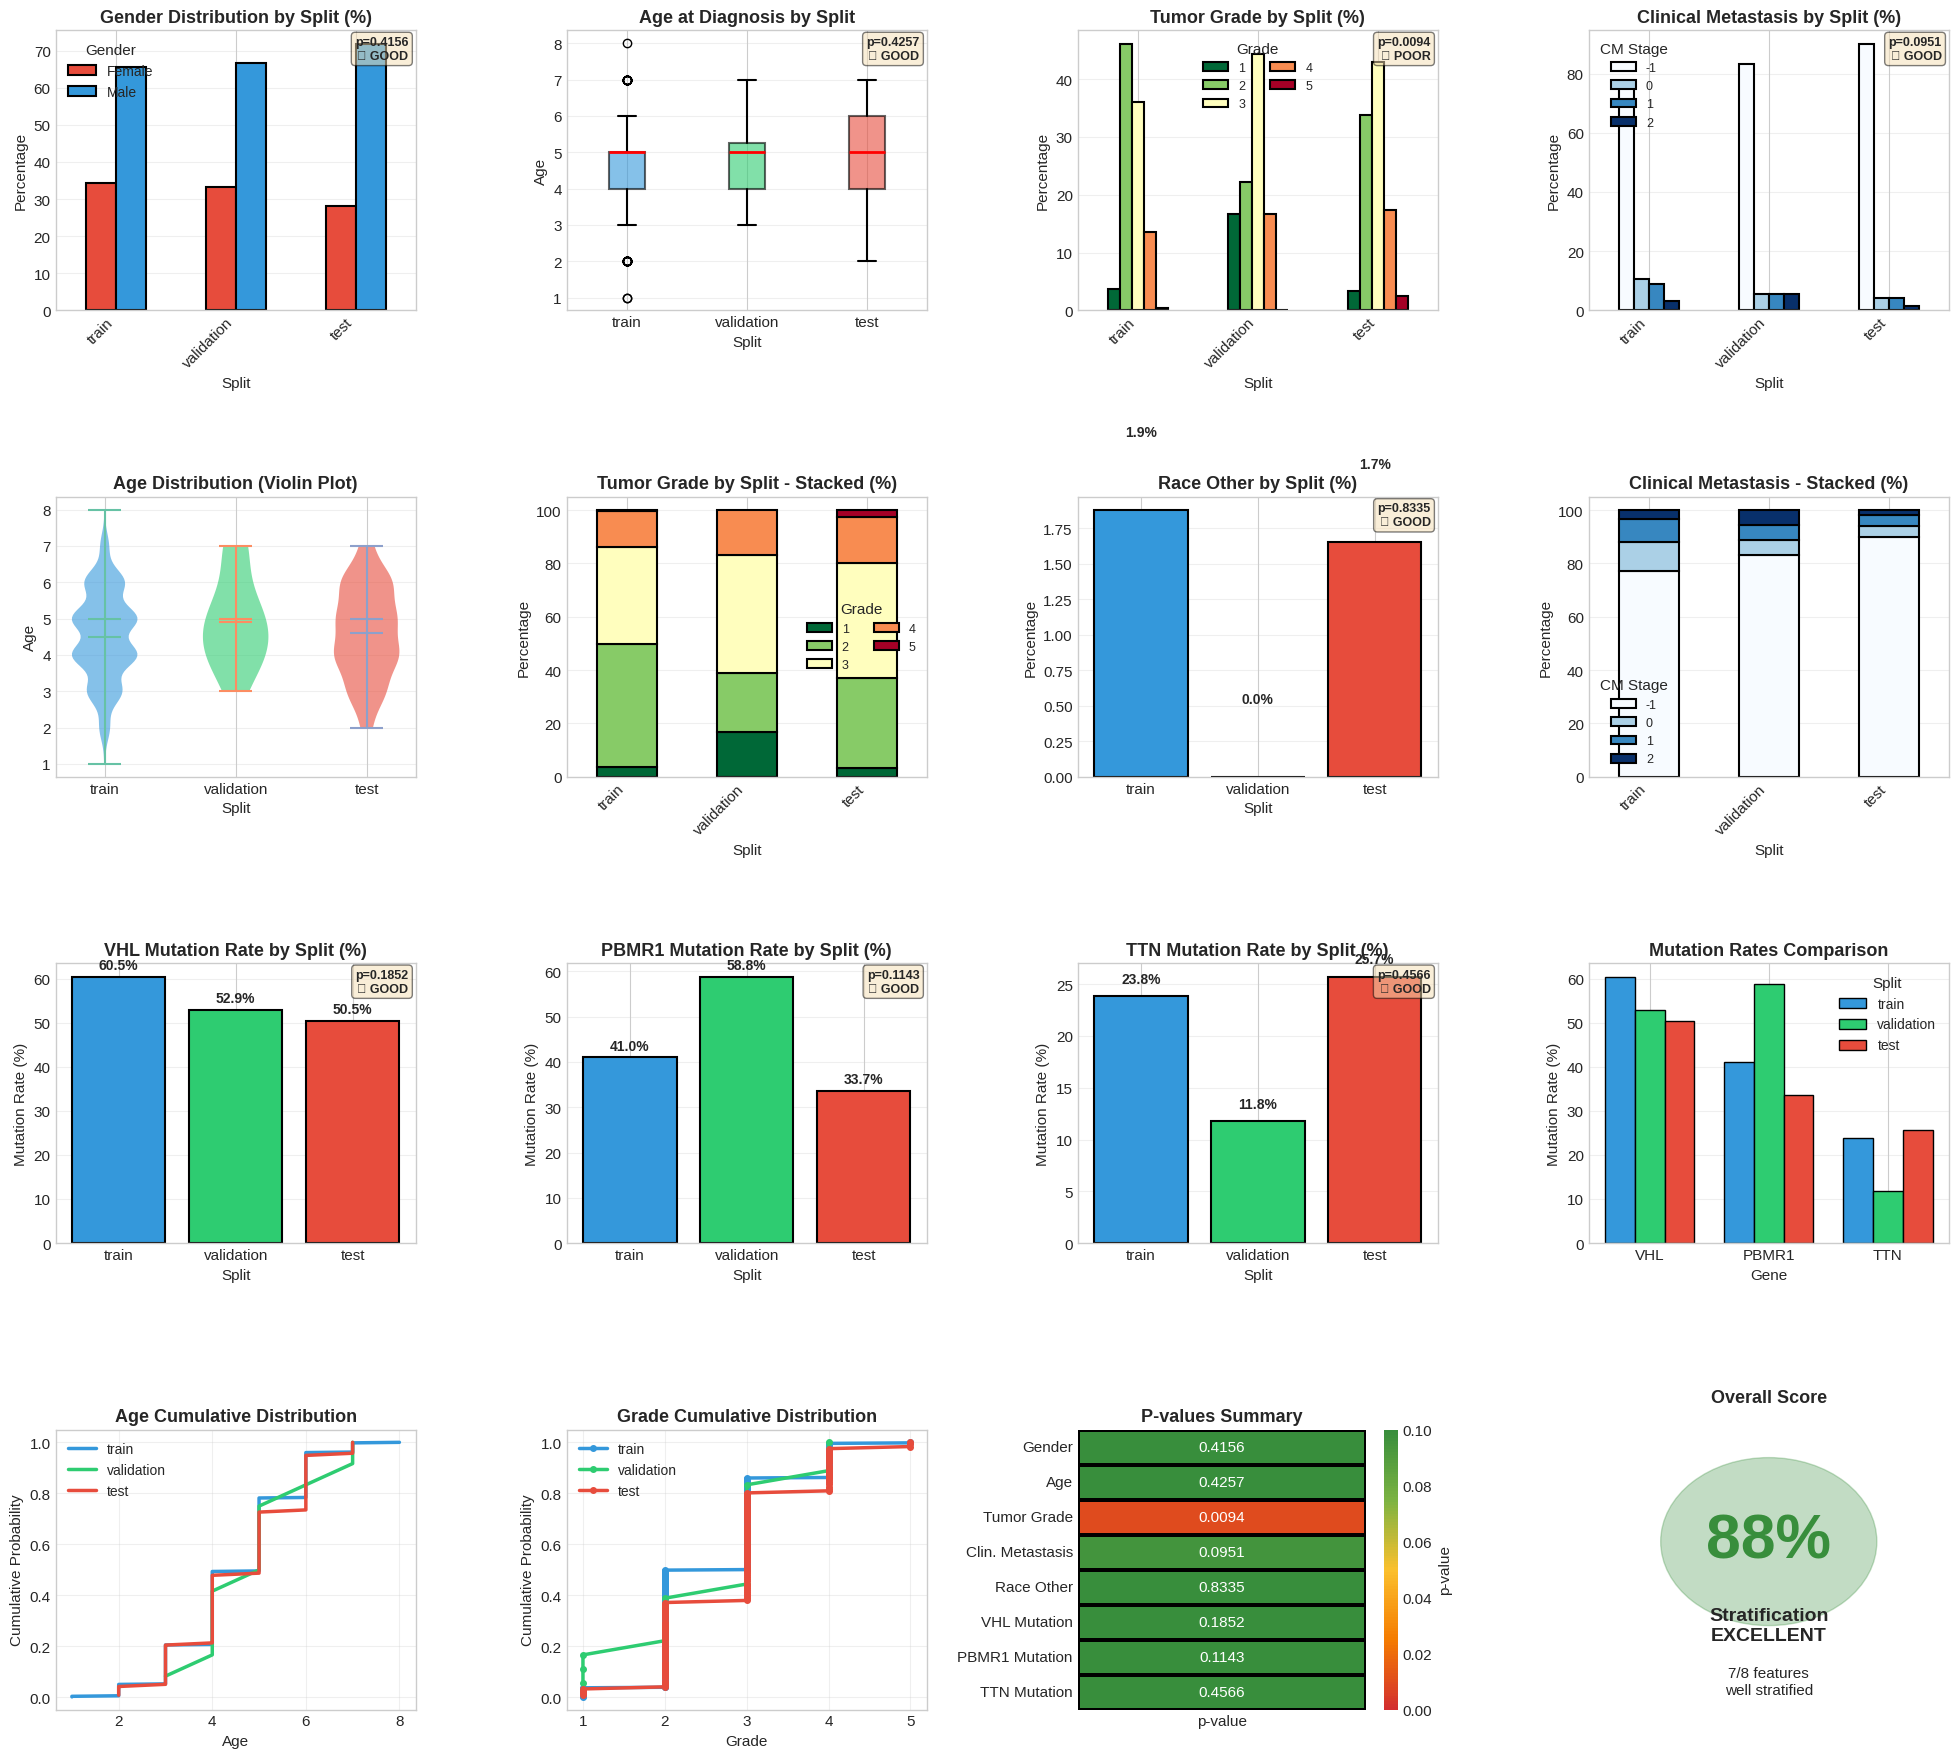

In [2]:
"""
Stratification Verification Script - Focused Analysis
Verifies stratification for: gender, age, grade, clinical metastasis, race_other, VHL, PBMR1, TTN mutations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (20, 16)
plt.rcParams['font.size'] = 11

# ============================================================================
# LOAD DATA
# ============================================================================

csv_path = "/media/Data/Yona/WSI CCRCC/tables/clinical+genomic_split.csv"
df = pd.read_csv(csv_path)

# Split order
split_order = ['train', 'validation', 'test']
split_colors = {'train': '#3498db', 'validation': '#2ecc71', 'test': '#e74c3c'}

print("="*120)
print(" "*45 + "STRATIFICATION VERIFICATION REPORT")
print("="*120)

print(f"\n📊 Total samples: {len(df)}")
print(f"\n📁 Split distribution:")
for split in split_order:
    count = len(df[df['Split'] == split])
    pct = count / len(df) * 100
    print(f"   • {split:12s}: {count:4d} samples ({pct:5.2f}%)")

# ============================================================================
# ANALYSIS FUNCTIONS
# ============================================================================

def test_categorical(df, feature, split_col='Split'):
    """Chi-square test for categorical variable"""
    contingency = pd.crosstab(df[split_col], df[feature])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    proportions = pd.crosstab(df[split_col], df[feature], normalize='index') * 100
    return {
        'chi2': chi2,
        'p_value': p_value,
        'proportions': proportions,
        'contingency': contingency
    }

def test_continuous(df, feature, split_col='Split'):
    """ANOVA test for continuous variable"""
    groups = [df[df[split_col] == split][feature].dropna() for split in split_order]
    f_stat, p_value = f_oneway(*groups)
    stats_by_split = df.groupby(split_col)[feature].agg(['mean', 'std', 'median', 'min', 'max', 'count'])
    return {
        'f_stat': f_stat,
        'p_value': p_value,
        'stats': stats_by_split,
        'groups': groups
    }

def interpret_p(p_value, alpha=0.05):
    """Interpret p-value"""
    if p_value > alpha:
        return "✓ GOOD", "No significant difference"
    elif p_value > alpha/2:
        return "⚠ FAIR", "Marginal difference"
    else:
        return "✗ POOR", "Significant difference"

# ============================================================================
# DETAILED ANALYSIS
# ============================================================================

print("\n" + "="*120)
print("DETAILED FEATURE ANALYSIS")
print("="*120)

results = {}

# ----------------------------------------------------------------------------
# 1. GENDER
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("1. GENDER")
print("-"*120)

result_gender = test_categorical(df, 'gender')
results['gender'] = result_gender

print(f"\n📊 Chi-square test: χ² = {result_gender['chi2']:.4f}, p-value = {result_gender['p_value']:.4f}")
status, msg = interpret_p(result_gender['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution by split (%):")
gender_labels = result_gender['proportions'].copy()
gender_labels.columns = ['Female', 'Male']
print(gender_labels.round(2).to_string())

# ----------------------------------------------------------------------------
# 2. AGE AT DIAGNOSIS
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("2. AGE AT DIAGNOSIS")
print("-"*120)

result_age = test_continuous(df, 'age_diag')
results['age_diag'] = result_age

print(f"\n📊 ANOVA test: F = {result_age['f_stat']:.4f}, p-value = {result_age['p_value']:.4f}")
status, msg = interpret_p(result_age['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Statistics by split:")
print(result_age['stats'].round(2).to_string())

# ----------------------------------------------------------------------------
# 3. TUMOR GRADE
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("3. TUMOR GRADE")
print("-"*120)

result_grade = test_categorical(df, 'grade')
results['grade'] = result_grade

print(f"\n📊 Chi-square test: χ² = {result_grade['chi2']:.4f}, p-value = {result_grade['p_value']:.4f}")
status, msg = interpret_p(result_grade['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution by split (%):")
print(result_grade['proportions'].round(2).to_string())

print("\n📊 Grade distribution by split:")
for split in split_order:
    split_df = df[df['Split'] == split]
    print(f"\n   {split}:")
    grade_counts = split_df['grade'].value_counts().sort_index()
    for grade, count in grade_counts.items():
        pct = count / len(split_df) * 100
        print(f"      Grade {grade}: {count:3d} ({pct:5.2f}%)")

# ----------------------------------------------------------------------------
# 4. CLINICAL METASTASIS (CM)
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("4. CLINICAL METASTASIS (ajcc_clin_metastasis_cm)")
print("-"*120)

result_cm = test_categorical(df, 'ajcc_clin_metastasis_cm')
results['ajcc_clin_metastasis_cm'] = result_cm

print(f"\n📊 Chi-square test: χ² = {result_cm['chi2']:.4f}, p-value = {result_cm['p_value']:.4f}")
status, msg = interpret_p(result_cm['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution by split (%):")
print(result_cm['proportions'].round(2).to_string())

# ----------------------------------------------------------------------------
# 5. RACE OTHER
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("5. RACE OTHER")
print("-"*120)

result_race = test_categorical(df, 'race_other')
results['race_other'] = result_race

print(f"\n📊 Chi-square test: χ² = {result_race['chi2']:.4f}, p-value = {result_race['p_value']:.4f}")
status, msg = interpret_p(result_race['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Distribution by split (%):")
race_prop = result_race['proportions'].copy()
race_prop.columns = ['No', 'Yes']
print(race_prop.round(2).to_string())

# Proportion by split
print("\n📊 Proportion of 'race_other' by split:")
for split in split_order:
    split_df = df[df['Split'] == split]
    rate = (split_df['race_other'] == 1).sum() / len(split_df) * 100
    n = (split_df['race_other'] == 1).sum()
    print(f"   • {split:12s}: {rate:5.2f}% ({n}/{len(split_df)})")

# ----------------------------------------------------------------------------
# 6. VHL MUTATION
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("6. VHL MUTATION")
print("-"*120)

df_vhl = df[df['VHL_mutation'].isin([0, 1])]
result_vhl = test_categorical(df_vhl, 'VHL_mutation')
results['VHL_mutation'] = result_vhl

print(f"\n📊 Samples with known status: {len(df_vhl)}/{len(df)}")
print(f"   Chi-square test: χ² = {result_vhl['chi2']:.4f}, p-value = {result_vhl['p_value']:.4f}")
status, msg = interpret_p(result_vhl['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Mutation rate by split:")
for split in split_order:
    split_df = df_vhl[df_vhl['Split'] == split]
    if len(split_df) > 0:
        mut_rate = (split_df['VHL_mutation'] == 1).sum() / len(split_df) * 100
        n_mut = (split_df['VHL_mutation'] == 1).sum()
        print(f"   • {split:12s}: {mut_rate:5.2f}% ({n_mut}/{len(split_df)})")

# ----------------------------------------------------------------------------
# 7. PBMR1 MUTATION
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("7. PBMR1 MUTATION")
print("-"*120)

df_pbmr1 = df[df['PBMR1_mutation'].isin([0, 1])]
result_pbmr1 = test_categorical(df_pbmr1, 'PBMR1_mutation')
results['PBMR1_mutation'] = result_pbmr1

print(f"\n📊 Samples with known status: {len(df_pbmr1)}/{len(df)}")
print(f"   Chi-square test: χ² = {result_pbmr1['chi2']:.4f}, p-value = {result_pbmr1['p_value']:.4f}")
status, msg = interpret_p(result_pbmr1['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Mutation rate by split:")
for split in split_order:
    split_df = df_pbmr1[df_pbmr1['Split'] == split]
    if len(split_df) > 0:
        mut_rate = (split_df['PBMR1_mutation'] == 1).sum() / len(split_df) * 100
        n_mut = (split_df['PBMR1_mutation'] == 1).sum()
        print(f"   • {split:12s}: {mut_rate:5.2f}% ({n_mut}/{len(split_df)})")

# ----------------------------------------------------------------------------
# 8. TTN MUTATION
# ----------------------------------------------------------------------------
print("\n" + "-"*120)
print("8. TTN MUTATION")
print("-"*120)

df_ttn = df[df['TTN_mutation'].isin([0, 1])]
result_ttn = test_categorical(df_ttn, 'TTN_mutation')
results['TTN_mutation'] = result_ttn

print(f"\n📊 Samples with known status: {len(df_ttn)}/{len(df)}")
print(f"   Chi-square test: χ² = {result_ttn['chi2']:.4f}, p-value = {result_ttn['p_value']:.4f}")
status, msg = interpret_p(result_ttn['p_value'])
print(f"   {status} stratification: {msg}")

print("\n📈 Mutation rate by split:")
for split in split_order:
    split_df = df_ttn[df_ttn['Split'] == split]
    if len(split_df) > 0:
        mut_rate = (split_df['TTN_mutation'] == 1).sum() / len(split_df) * 100
        n_mut = (split_df['TTN_mutation'] == 1).sum()
        print(f"   • {split:12s}: {mut_rate:5.2f}% ({n_mut}/{len(split_df)})")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\n" + "="*120)
print("GENERATING VISUALIZATIONS")
print("="*120)

fig = plt.figure(figsize=(20, 18))

# ----------------------------------------------------------------------------
# ROW 1: GENDER, AGE, GRADE, CLINICAL METASTASIS
# ----------------------------------------------------------------------------

# 1. Gender by split
ax1 = plt.subplot(4, 4, 1)
gender_prop = pd.crosstab(df['Split'], df['gender'], normalize='index') * 100
gender_prop = gender_prop.reindex(split_order)
gender_prop.columns = ['Female', 'Male']
gender_prop.plot(kind='bar', ax=ax1, color=['#e74c3c', '#3498db'], 
                 edgecolor='black', linewidth=1.5)
ax1.set_title('Gender Distribution by Split (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Split', fontsize=11)
ax1.set_ylabel('Percentage', fontsize=11)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend(title='Gender', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
# Add p-value
p_val = results['gender']['p_value']
status, _ = interpret_p(p_val)
ax1.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax1.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 2. Age boxplot by split
ax2 = plt.subplot(4, 4, 2)
split_data = [df[df['Split'] == split]['age_diag'].dropna() for split in split_order]
bp = ax2.boxplot(split_data, labels=split_order, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))
for patch, split in zip(bp['boxes'], split_order):
    patch.set_facecolor(split_colors[split])
    patch.set_alpha(0.6)
ax2.set_title('Age at Diagnosis by Split', fontsize=13, fontweight='bold')
ax2.set_xlabel('Split', fontsize=11)
ax2.set_ylabel('Age', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
# Add p-value
p_val = results['age_diag']['p_value']
status, _ = interpret_p(p_val)
ax2.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax2.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 3. Tumor Grade by split
ax3 = plt.subplot(4, 4, 3)
grade_prop = pd.crosstab(df['Split'], df['grade'], normalize='index') * 100
grade_prop = grade_prop.reindex(split_order)
grade_prop.plot(kind='bar', ax=ax3, stacked=False, colormap='RdYlGn_r',
                edgecolor='black', linewidth=1.5)
ax3.set_title('Tumor Grade by Split (%)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Split', fontsize=11)
ax3.set_ylabel('Percentage', fontsize=11)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.legend(title='Grade', fontsize=9, ncol=2)
ax3.grid(axis='y', alpha=0.3)
# Add p-value
p_val = results['grade']['p_value']
status, _ = interpret_p(p_val)
ax3.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax3.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 4. Clinical Metastasis by split
ax4 = plt.subplot(4, 4, 4)
cm_prop = pd.crosstab(df['Split'], df['ajcc_clin_metastasis_cm'], normalize='index') * 100
cm_prop = cm_prop.reindex(split_order)
cm_prop.plot(kind='bar', ax=ax4, stacked=False, colormap='Blues',
             edgecolor='black', linewidth=1.5)
ax4.set_title('Clinical Metastasis by Split (%)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Split', fontsize=11)
ax4.set_ylabel('Percentage', fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(title='CM Stage', fontsize=9)
ax4.grid(axis='y', alpha=0.3)
# Add p-value
p_val = results['ajcc_clin_metastasis_cm']['p_value']
status, _ = interpret_p(p_val)
ax4.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax4.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# ----------------------------------------------------------------------------
# ROW 2: AGE VIOLIN, GRADE STACKED, RACE OTHER, CM STACKED
# ----------------------------------------------------------------------------

# 5. Age violin plot
ax5 = plt.subplot(4, 4, 5)
df_age = df.dropna(subset=['age_diag'])
for i, split in enumerate(split_order):
    data = df_age[df_age['Split'] == split]['age_diag']
    parts = ax5.violinplot([data], positions=[i], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(split_colors[split])
        pc.set_alpha(0.6)
ax5.set_xticks(range(len(split_order)))
ax5.set_xticklabels(split_order)
ax5.set_title('Age Distribution (Violin Plot)', fontsize=13, fontweight='bold')
ax5.set_xlabel('Split', fontsize=11)
ax5.set_ylabel('Age', fontsize=11)
ax5.grid(axis='y', alpha=0.3)

# 6. Grade stacked bar chart
ax6 = plt.subplot(4, 4, 6)
grade_prop_stacked = pd.crosstab(df['Split'], df['grade'], normalize='index') * 100
grade_prop_stacked = grade_prop_stacked.reindex(split_order)
grade_prop_stacked.plot(kind='bar', ax=ax6, stacked=True, colormap='RdYlGn_r',
                        edgecolor='black', linewidth=1.5)
ax6.set_title('Tumor Grade by Split - Stacked (%)', fontsize=13, fontweight='bold')
ax6.set_xlabel('Split', fontsize=11)
ax6.set_ylabel('Percentage', fontsize=11)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right')
ax6.legend(title='Grade', fontsize=9, ncol=2)
ax6.grid(axis='y', alpha=0.3)

# 7. Race other by split
ax7 = plt.subplot(4, 4, 7)
race_rates = []
for split in split_order:
    split_df = df[df['Split'] == split]
    rate = (split_df['race_other'] == 1).sum() / len(split_df) * 100
    race_rates.append(rate)

bars = ax7.bar(split_order, race_rates, 
               color=[split_colors[s] for s in split_order],
               edgecolor='black', linewidth=1.5)
ax7.set_title('Race Other by Split (%)', fontsize=13, fontweight='bold')
ax7.set_xlabel('Split', fontsize=11)
ax7.set_ylabel('Percentage', fontsize=11)
ax7.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, race_rates):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
# Add p-value
p_val = results['race_other']['p_value']
status, _ = interpret_p(p_val)
ax7.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax7.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 8. Clinical Metastasis stacked
ax8 = plt.subplot(4, 4, 8)
cm_prop_stacked = pd.crosstab(df['Split'], df['ajcc_clin_metastasis_cm'], normalize='index') * 100
cm_prop_stacked = cm_prop_stacked.reindex(split_order)
cm_prop_stacked.plot(kind='bar', ax=ax8, stacked=True, colormap='Blues',
                     edgecolor='black', linewidth=1.5)
ax8.set_title('Clinical Metastasis - Stacked (%)', fontsize=13, fontweight='bold')
ax8.set_xlabel('Split', fontsize=11)
ax8.set_ylabel('Percentage', fontsize=11)
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=45, ha='right')
ax8.legend(title='CM Stage', fontsize=9)
ax8.grid(axis='y', alpha=0.3)

# ----------------------------------------------------------------------------
# ROW 3: MUTATIONS VHL, PBMR1, TTN
# ----------------------------------------------------------------------------

# 9. VHL mutation by split
ax9 = plt.subplot(4, 4, 9)
vhl_rates = []
for split in split_order:
    split_df = df_vhl[df_vhl['Split'] == split]
    if len(split_df) > 0:
        rate = (split_df['VHL_mutation'] == 1).sum() / len(split_df) * 100
    else:
        rate = 0
    vhl_rates.append(rate)

bars = ax9.bar(split_order, vhl_rates,
               color=[split_colors[s] for s in split_order],
               edgecolor='black', linewidth=1.5)
ax9.set_title('VHL Mutation Rate by Split (%)', fontsize=13, fontweight='bold')
ax9.set_xlabel('Split', fontsize=11)
ax9.set_ylabel('Mutation Rate (%)', fontsize=11)
ax9.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, vhl_rates):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
# Add p-value
p_val = results['VHL_mutation']['p_value']
status, _ = interpret_p(p_val)
ax9.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
         transform=ax9.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         fontsize=9, fontweight='bold')

# 10. PBMR1 mutation by split
ax10 = plt.subplot(4, 4, 10)
pbmr1_rates = []
for split in split_order:
    split_df = df_pbmr1[df_pbmr1['Split'] == split]
    if len(split_df) > 0:
        rate = (split_df['PBMR1_mutation'] == 1).sum() / len(split_df) * 100
    else:
        rate = 0
    pbmr1_rates.append(rate)

bars = ax10.bar(split_order, pbmr1_rates,
                color=[split_colors[s] for s in split_order],
                edgecolor='black', linewidth=1.5)
ax10.set_title('PBMR1 Mutation Rate by Split (%)', fontsize=13, fontweight='bold')
ax10.set_xlabel('Split', fontsize=11)
ax10.set_ylabel('Mutation Rate (%)', fontsize=11)
ax10.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, pbmr1_rates):
    height = bar.get_height()
    ax10.text(bar.get_x() + bar.get_width()/2., height + 1,
              f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
# Add p-value
p_val = results['PBMR1_mutation']['p_value']
status, _ = interpret_p(p_val)
ax10.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
          transform=ax10.transAxes, ha='right', va='top',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
          fontsize=9, fontweight='bold')

# 11. TTN mutation by split
ax11 = plt.subplot(4, 4, 11)
ttn_rates = []
for split in split_order:
    split_df = df_ttn[df_ttn['Split'] == split]
    if len(split_df) > 0:
        rate = (split_df['TTN_mutation'] == 1).sum() / len(split_df) * 100
    else:
        rate = 0
    ttn_rates.append(rate)

bars = ax11.bar(split_order, ttn_rates,
                color=[split_colors[s] for s in split_order],
                edgecolor='black', linewidth=1.5)
ax11.set_title('TTN Mutation Rate by Split (%)', fontsize=13, fontweight='bold')
ax11.set_xlabel('Split', fontsize=11)
ax11.set_ylabel('Mutation Rate (%)', fontsize=11)
ax11.grid(axis='y', alpha=0.3)
for bar, rate in zip(bars, ttn_rates):
    height = bar.get_height()
    ax11.text(bar.get_x() + bar.get_width()/2., height + 1,
              f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
# Add p-value
p_val = results['TTN_mutation']['p_value']
status, _ = interpret_p(p_val)
ax11.text(0.98, 0.98, f'p={p_val:.4f}\n{status}', 
          transform=ax11.transAxes, ha='right', va='top',
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
          fontsize=9, fontweight='bold')

# 12. Mutation comparison across splits
ax12 = plt.subplot(4, 4, 12)
mutation_data = []
for split in split_order:
    split_rates = []
    for mut_col, df_mut in [('VHL', df_vhl), ('PBMR1', df_pbmr1), ('TTN', df_ttn)]:
        split_df = df_mut[df_mut['Split'] == split]
        if len(split_df) > 0:
            if mut_col == 'VHL':
                rate = (split_df['VHL_mutation'] == 1).sum() / len(split_df) * 100
            elif mut_col == 'PBMR1':
                rate = (split_df['PBMR1_mutation'] == 1).sum() / len(split_df) * 100
            else:
                rate = (split_df['TTN_mutation'] == 1).sum() / len(split_df) * 100
        else:
            rate = 0
        split_rates.append(rate)
    mutation_data.append(split_rates)

x = np.arange(len(['VHL', 'PBMR1', 'TTN']))
width = 0.25
for i, (split, data) in enumerate(zip(split_order, mutation_data)):
    ax12.bar(x + i*width, data, width, label=split, 
             color=split_colors[split], edgecolor='black', linewidth=1)

ax12.set_title('Mutation Rates Comparison', fontsize=13, fontweight='bold')
ax12.set_xlabel('Gene', fontsize=11)
ax12.set_ylabel('Mutation Rate (%)', fontsize=11)
ax12.set_xticks(x + width)
ax12.set_xticklabels(['VHL', 'PBMR1', 'TTN'])
ax12.legend(title='Split', fontsize=10)
ax12.grid(axis='y', alpha=0.3)

# ----------------------------------------------------------------------------
# ROW 4: CUMULATIVE DISTRIBUTIONS AND SUMMARY
# ----------------------------------------------------------------------------

# 13. Age cumulative distribution
ax13 = plt.subplot(4, 4, 13)
for split in split_order:
    data = df[df['Split'] == split]['age_diag'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax13.plot(sorted_data, cumulative, label=split, linewidth=2.5,
              color=split_colors[split])
ax13.set_title('Age Cumulative Distribution', fontsize=13, fontweight='bold')
ax13.set_xlabel('Age', fontsize=11)
ax13.set_ylabel('Cumulative Probability', fontsize=11)
ax13.legend(fontsize=10)
ax13.grid(alpha=0.3)

# 14. Grade cumulative distribution
ax14 = plt.subplot(4, 4, 14)
for split in split_order:
    data = df[df['Split'] == split]['grade']
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax14.plot(sorted_data, cumulative, label=split, linewidth=2.5,
              color=split_colors[split], marker='o', markersize=4)
ax14.set_title('Grade Cumulative Distribution', fontsize=13, fontweight='bold')
ax14.set_xlabel('Grade', fontsize=11)
ax14.set_ylabel('Cumulative Probability', fontsize=11)
ax14.legend(fontsize=10)
ax14.grid(alpha=0.3)

# 15. P-values heatmap
ax15 = plt.subplot(4, 4, 15)
p_values_data = []
feature_names = []

feature_labels = {
    'gender': 'Gender',
    'age_diag': 'Age',
    'grade': 'Tumor Grade',
    'ajcc_clin_metastasis_cm': 'Clin. Metastasis',
    'race_other': 'Race Other',
    'VHL_mutation': 'VHL Mutation',
    'PBMR1_mutation': 'PBMR1 Mutation',
    'TTN_mutation': 'TTN Mutation'
}

for feat in ['gender', 'age_diag', 'grade', 'ajcc_clin_metastasis_cm', 'race_other', 
             'VHL_mutation', 'PBMR1_mutation', 'TTN_mutation']:
    if feat in results:
        p_values_data.append([results[feat]['p_value']])
        feature_names.append(feature_labels[feat])

p_df = pd.DataFrame(p_values_data, index=feature_names, columns=['p-value'])

from matplotlib.colors import LinearSegmentedColormap
colors_cmap = ['#d32f2f', '#f57c00', '#fbc02d', '#7cb342', '#388e3c']
cmap = LinearSegmentedColormap.from_list('pvalue', colors_cmap, N=100)

sns.heatmap(p_df, annot=True, fmt='.4f', cmap=cmap, 
            vmin=0, vmax=0.1, cbar_kws={'label': 'p-value'},
            ax=ax15, linewidths=1.5, linecolor='black')
ax15.set_title('P-values Summary', fontsize=13, fontweight='bold')
ax15.set_ylabel('')

# 16. Stratification summary
ax16 = plt.subplot(4, 4, 16)
ax16.axis('off')

statuses = {'✓ GOOD': 0, '⚠ FAIR': 0, '✗ POOR': 0}
for feat, result in results.items():
    if 'p_value' in result:
        status, _ = interpret_p(result['p_value'])
        statuses[status] += 1

total_tests = sum(statuses.values())
good_pct = statuses['✓ GOOD'] / total_tests * 100 if total_tests > 0 else 0

if good_pct >= 80:
    score_color = '#388e3c'
    score_text = 'EXCELLENT'
elif good_pct >= 60:
    score_color = '#7cb342'
    score_text = 'GOOD'
elif good_pct >= 40:
    score_color = '#f57c00'
    score_text = 'FAIR'
else:
    score_color = '#d32f2f'
    score_text = 'POOR'

circle = plt.Circle((0.5, 0.6), 0.3, color=score_color, alpha=0.3)
ax16.add_patch(circle)
ax16.text(0.5, 0.6, f'{good_pct:.0f}%', ha='center', va='center',
          fontsize=45, fontweight='bold', color=score_color)
ax16.text(0.5, 0.3, f'Stratification\n{score_text}', ha='center', va='center',
          fontsize=14, fontweight='bold')
ax16.text(0.5, 0.1, f'{statuses["✓ GOOD"]}/{total_tests} features\nwell stratified', 
          ha='center', va='center', fontsize=11)
ax16.set_xlim(0, 1)
ax16.set_ylim(0, 1)
ax16.set_title('Overall Score', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout(pad=2.0)
plt.savefig('stratification_verification.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: stratification_verification.png")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*120)
print("FINAL SUMMARY")
print("="*120)

print(f"\n📊 OVERALL SCORE: {good_pct:.1f}% ({score_text})")
print(f"   • Total tests: {total_tests}")
print(f"   • Good stratifications (p > 0.05): {statuses['✓ GOOD']}")
print(f"   • Fair stratifications (0.025 < p ≤ 0.05): {statuses['⚠ FAIR']}")
print(f"   • Poor stratifications (p ≤ 0.025): {statuses['✗ POOR']}")

# Identify problematic features
problematic = []
for feat, result in results.items():
    if 'p_value' in result and result['p_value'] < 0.05:
        problematic.append((feature_labels.get(feat, feat), result['p_value']))

if problematic:
    print("\n⚠️  FEATURES WITH STRATIFICATION ISSUES (p < 0.05):")
    for feat, p_val in sorted(problematic, key=lambda x: x[1]):
        print(f"   • {feat:25s}: p = {p_val:.4f}")
    print("\n💡 RECOMMENDATIONS:")
    print("   1. Review stratification strategy for these features")
    print("   2. Consider re-sampling or stratified splitting")
    print("   3. Document these differences in your methodology")
else:
    print("\n✓ All features are well stratified across train/validation/test splits")

# Validation set warning
val_size = len(df[df['Split'] == 'validation'])
val_pct = val_size / len(df) * 100
if val_pct < 10:
    print(f"\n⚠️  WARNING: Validation set is very small ({val_size} samples, {val_pct:.1f}%)")
    print("   • Recommendation: Increase validation set to 10-20% of data")
    print("   • Alternative: Use cross-validation on training set")

print("\n" + "="*120)
print("✓ ANALYSIS COMPLETED SUCCESSFULLY")
print("="*120)
print("\n📁 Output file: stratification_verification.png")

plt.show()